# V2: Leave-One-Bearing-Out Training with a Degradation-Timeline RUL Target

Companion to `explainable_dual_head_bearing_prognostics.ipynb` (that notebook and its results are left unchanged).
This notebook changes three things, and only these:

1. **All 6 learning bearings are used for training** (the original used 3 for training + 3 for validation).
2. **Leave-one-bearing-out (LOBO) validation**: each learning bearing is held out in turn while the model trains on the other five. Epochs are fixed in advance (25), so the held-out bearing never influences training or model selection.
3. **New target built from each bearing's own degradation timeline** instead of one global cap taken from the longest bearing (Bearing1_1). For every bearing a *degradation onset* is found; RUL target is $y=1$ before onset and falls linearly from 1 to 0 between onset and failure (the fraction of the degradation phase still remaining).

The final model is trained on all 6 learning bearings and scored **once** on the 11 held-out test bearings.

> **Important:** the new target is *not on the same scale* as the old capped RUL (it is a fraction of each bearing's degradation phase, not minutes), so v2 numbers must not be compared with the old MAE in minutes. Every table therefore contains its own **constant-prediction baseline**, and the comparison that matters is *model vs baseline within the same target*.

**How the onset is defined (label side only; the model never sees it):** health indicator $HI_t=\log\sqrt{RMS_h^2+RMS_v^2}$ (median-smoothed). Baseline = median of the lowest 30% of HI values of that bearing; level at failure = max of lightly smoothed HI. The onset is the start of the **final uninterrupted excursion** above `baseline + 10% x (failure level - baseline)`. Using the final excursion means mid-life wobbles that return to baseline are not mistaken for degradation. The 10% fraction was fixed before looking at any model results. Because the onset is found with hindsight it is a **label definition** (like knowing the failure time), not something available at prediction time.


In [1]:
# ==============================================================================
# 0. SETUP  (reuses the features already extracted by the original notebook)
# ==============================================================================
import os, sys, time, json, random, numpy as np, pandas as pd
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import roc_auc_score, f1_score

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()      # same seed -> same numbers on CPU
BASE_DIR = os.path.abspath(".")
RESULTS_DIR = os.path.join(BASE_DIR, "results")
FIG_DIR = os.path.join(RESULTS_DIR, "figures_v2"); os.makedirs(FIG_DIR, exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 100, "savefig.dpi": 300, "savefig.bbox": "tight", "axes.titlesize": 12})

a = pd.read_csv(os.path.join(RESULTS_DIR, 'extracted_bearing_features.csv'))
b = pd.read_csv(os.path.join(RESULTS_DIR, 'extracted_features_all_11_test_bearings.csv'))
df = pd.concat([a, b]).drop_duplicates(['bearing', 'snapshot_idx']).sort_values(['bearing', 'snapshot_idx']).reset_index(drop=True)
F = [c for c in df.columns if c.startswith(('horiz_', 'vert_'))]
LEARN = ['Bearing1_1', 'Bearing1_2', 'Bearing2_1', 'Bearing2_2', 'Bearing3_1', 'Bearing3_2']   # 6 learning bearings
TEST = ['Bearing1_3', 'Bearing1_4', 'Bearing1_5', 'Bearing1_6', 'Bearing1_7', 'Bearing2_3',
        'Bearing2_4', 'Bearing2_5', 'Bearing2_6', 'Bearing2_7', 'Bearing3_3']                  # 11 test bearings
assert set(LEARN) | set(TEST) == set(df.bearing) and not set(LEARN) & set(TEST)
WINDOW, EPOCHS, ONSET_FRAC = 16, 25, 0.10
import sklearn, scipy, platform
HPARAMS = dict(seed=SEED, window=WINDOW, epochs=EPOCHS, batch_size=64, learning_rate=1e-3, dropout=0.2, conv_filters=64, conv_kernel=3,
               lstm_units=64, shared_dense=64, head_dense=32, loss_weights={'rul': 1.0, 'risk': 0.5}, onset_fraction=ONSET_FRAC,
               onset_smooth_window=15, onset_end_smooth_window=5, onset_baseline_quantile=0.30, critical_stage_threshold=0.35,
               regression_to_stage_thresholds=[0.90, 0.35], degradation_weight_cap=10, alarm_persistence_windows=3,
               random_forest=dict(n_estimators=200, min_samples_leaf=5), ridge_alpha=1.0, test_seeds=[42, 43, 44],
               versions=dict(python=platform.python_version(), numpy=np.__version__, pandas=pd.__version__, sklearn=sklearn.__version__,
                             scipy=scipy.__version__, tensorflow=tf.__version__))
json.dump(HPARAMS, open(os.path.join(RESULTS_DIR, 'v2_run_config.json'), 'w'), indent=2)
print(json.dumps(HPARAMS['versions']))
print(f"{len(F)} features | {len(LEARN)} learning bearings | {len(TEST)} test bearings | {len(df):,} snapshots | TF {tf.__version__}")


{"python": "3.12.6", "numpy": "2.2.6", "pandas": "2.2.2", "sklearn": "1.5.2", "scipy": "1.14.1", "tensorflow": "2.20.0"}
30 features | 6 learning bearings | 11 test bearings | 24,889 snapshots | TF 2.20.0


,bearing,snapshots,onset_idx,set,onset_at_%_of_life,degradation_phase_min
0,Bearing1_1,2803,1452,learn,51.8,225.0
1,Bearing1_2,871,824,learn,94.6,7.7
2,Bearing1_3,2375,1605,test,67.6,128.2
3,Bearing1_4,1428,1087,test,76.1,56.7
4,Bearing1_5,2463,2408,test,97.8,9.0
5,Bearing1_6,2448,2412,test,98.5,5.8
6,Bearing1_7,2259,1207,test,53.4,175.2
7,Bearing2_1,911,150,learn,16.5,126.7
8,Bearing2_2,797,193,learn,24.2,100.5
9,Bearing2_3,1955,1946,test,99.5,1.3


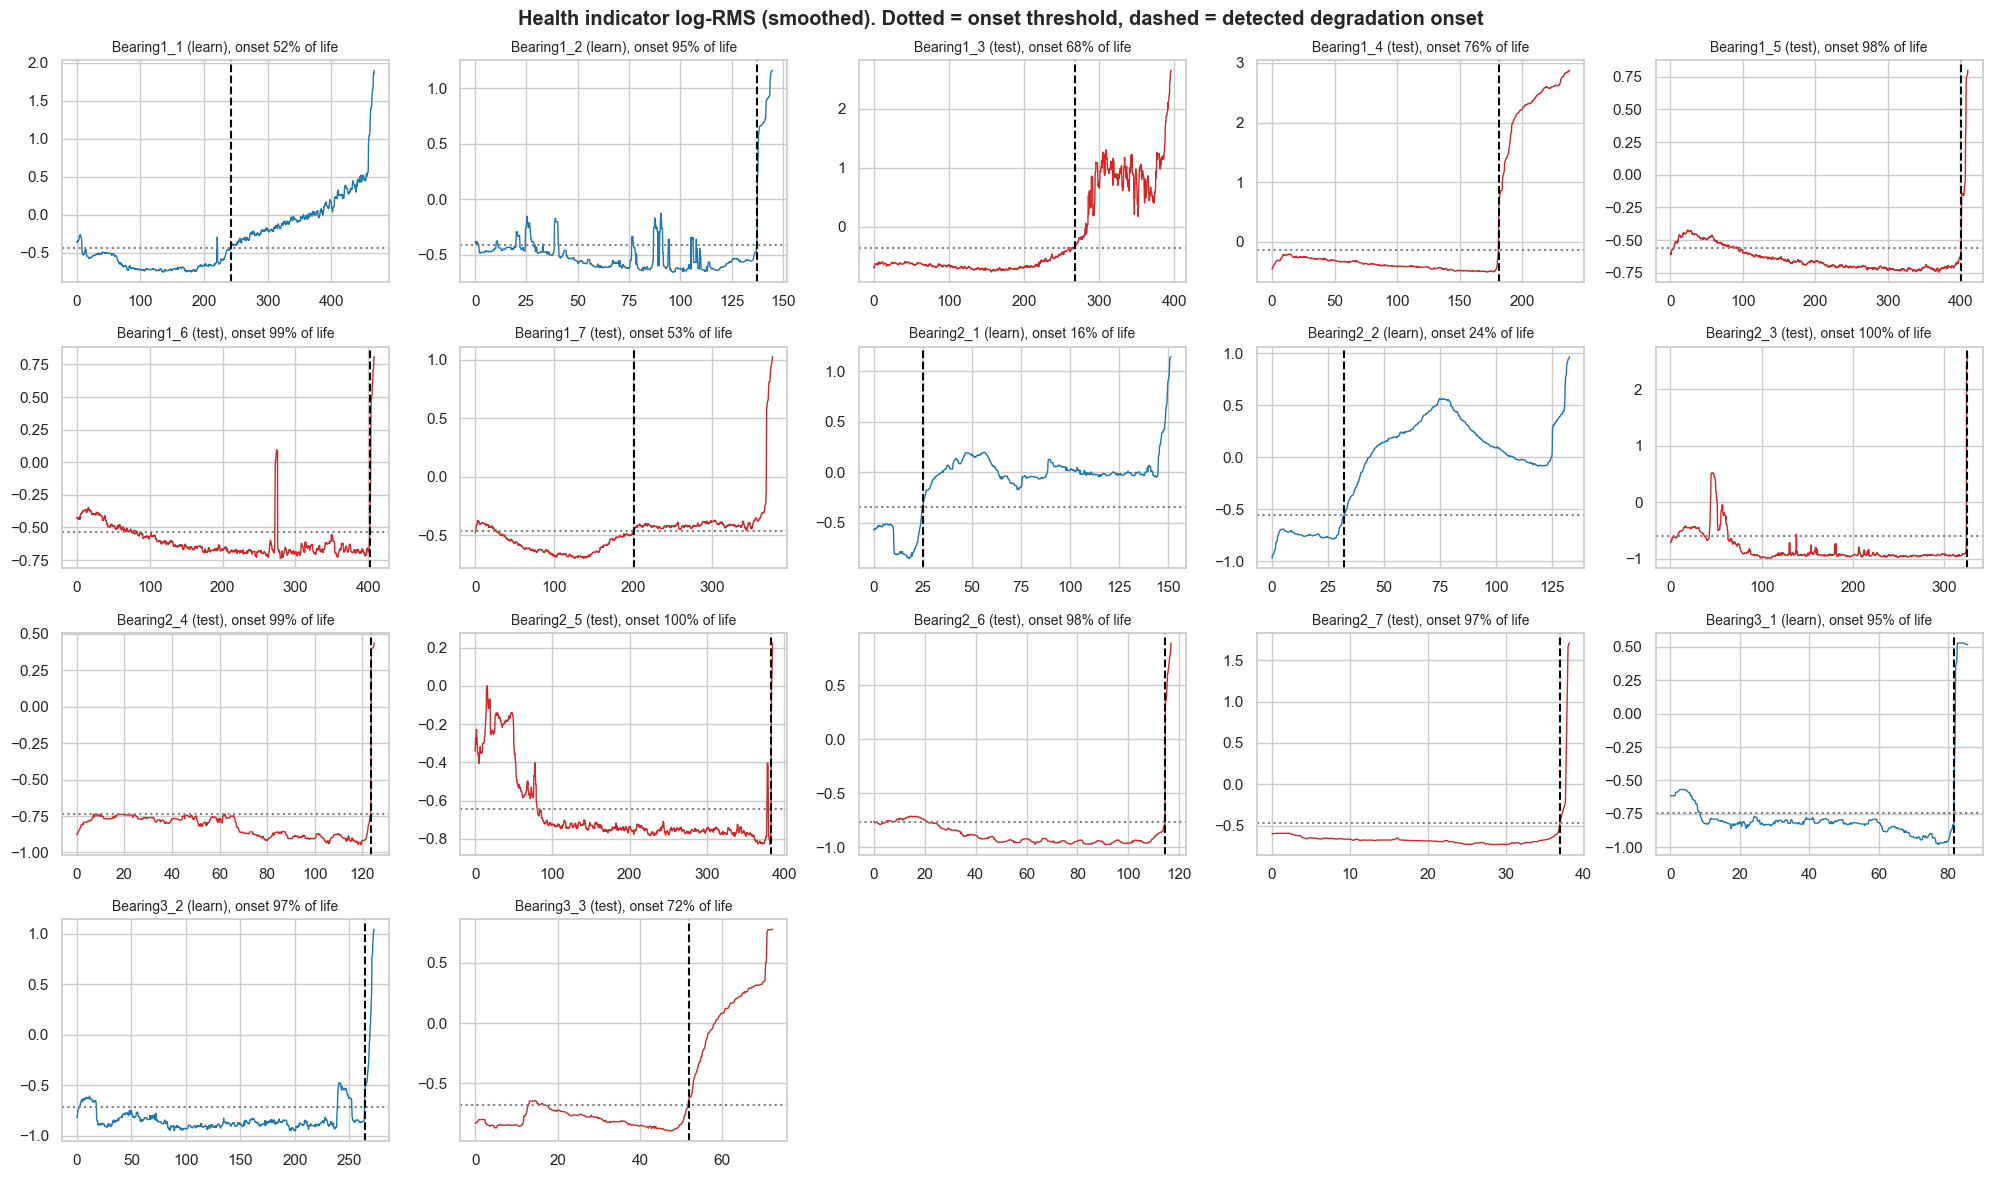

In [2]:
# ==============================================================================
# 1. DEGRADATION ONSET PER BEARING  ->  DEGRADATION-TIMELINE RUL TARGET
# ==============================================================================
sm = lambda x, w: pd.Series(x).rolling(w, min_periods=1, center=True).median().values

def find_onset(g, frac=ONSET_FRAC):
    """Start of the FINAL uninterrupted excursion of the health indicator above baseline + frac*(failure level - baseline)."""
    hi = np.log(np.sqrt(g['horiz_rms'].values ** 2 + g['vert_rms'].values ** 2))
    h = sm(hi, 15); n = len(h)
    base = np.median(np.sort(h)[:int(0.3 * n)]); end = sm(hi, 5).max()
    thr = base + frac * (end - base)
    below = np.where(h < thr)[0]
    return (below[-1] + 1 if len(below) else 0), h, thr

STAGE_T = 0.35            # Critical when <35% of the degradation phase remains
lab = []
for bn, g in df.groupby('bearing'):
    g = g.sort_values('snapshot_idx'); n = len(g)
    on, _, _ = find_onset(g); on = min(on, n - 2)             # keep >= 1 degradation step
    idx = np.arange(n)
    y = np.where(idx <= on, 1.0, (n - 1 - idx) / (n - 1 - on))
    stage = np.where(idx <= on, 0, np.where(y > STAGE_T, 1, 2))
    lab.append(pd.DataFrame({'bearing': bn, 'snapshot_idx': idx, 'onset_idx': on, 'y_deg': y, 'stage_deg': stage,
                             'post_onset': (idx > on).astype(int), 't_min': idx * 10 / 60.0}))
df = df.merge(pd.concat(lab), on=['bearing', 'snapshot_idx'])
summ = df.groupby('bearing').agg(snapshots=('snapshot_idx', 'size'), onset_idx=('onset_idx', 'first')).reset_index()
summ['set'] = np.where(summ.bearing.isin(LEARN), 'learn', 'test')
summ['onset_at_%_of_life'] = (100 * summ.onset_idx / summ.snapshots).round(1)
summ['degradation_phase_min'] = ((summ.snapshots - 1 - summ.onset_idx) * 10 / 60).round(1)
display(summ)

# ---- Figure V1: health indicator + detected onset for all 17 bearings (visual check of the label rule) ----
fig, axes = plt.subplots(4, 5, figsize=(20, 12)); axes = axes.ravel()
for ax, (bn, g) in zip(axes, df.groupby('bearing')):
    g = g.sort_values('snapshot_idx'); on, h, thr = find_onset(g)
    ax.plot(g['t_min'], h, color='#1f77b4' if bn in LEARN else '#d62728', lw=1)
    ax.axhline(thr, color='gray', ls=':'); ax.axvline(g['t_min'].iloc[min(on, len(g) - 1)], color='black', ls='--')
    ax.set_title(f"{bn} ({'learn' if bn in LEARN else 'test'}), onset {100*on/len(g):.0f}% of life", fontsize=10)
for ax in axes[len(df.bearing.unique()):]: ax.axis('off')
fig.suptitle('Health indicator log-RMS (smoothed). Dotted = onset threshold, dashed = detected degradation onset', fontweight='bold')
plt.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'figV1_onset_detection.png')); plt.show()


In [3]:
# ==============================================================================
# 2. WINDOWS, MODELS, TRAINING RECIPE AND METRICS
# ==============================================================================
@tf.keras.utils.register_keras_serializable()
class TemporalAttention(layers.Layer):
    def build(self, s):
        d = s[-1]
        self.W = self.add_weight(name='w', shape=(d, d), initializer='glorot_uniform')
        self.b = self.add_weight(name='b', shape=(d,), initializer='zeros')
        self.u = self.add_weight(name='u', shape=(d, 1), initializer='glorot_uniform')
    def call(self, x):
        w = tf.nn.softmax(tf.tensordot(tf.tanh(tf.tensordot(x, self.W, 1) + self.b), self.u, 1), axis=1)
        return tf.reduce_sum(x * w, axis=1), w

def make_windows(bearings, scaler):
    X, y, s, meta = [], [], [], []
    for bn in bearings:
        g = df[df.bearing == bn].sort_values('snapshot_idx'); x = scaler.transform(g[F])
        for i in range(len(g) - WINDOW + 1):
            j = i + WINDOW - 1
            X.append(x[i:j + 1]); y.append(g.y_deg.values[j]); s.append(g.stage_deg.values[j])
            meta.append((bn, g.snapshot_idx.values[j], g.t_min.values[j], g.post_onset.values[j]))
    return (np.array(X, 'f'), np.array(y, 'f'), np.array(s, 'i'),
            pd.DataFrame(meta, columns=['bearing', 'snapshot_idx', 't_min', 'post_onset']))

def class_weights(post):
    """Degradation windows are rare (most of a life is healthy): up-weight them so 'always healthy' is not optimal."""
    w = np.ones(len(post), 'f'); w[post == 1] = min(10.0, (post == 0).sum() / max(1, (post == 1).sum())); return w

def build_variant(kind, dual=True, nf=30):
    inp = layers.Input(shape=(WINDOW, nf)); x = inp
    if kind in ('cnn', 'cnn_bilstm', 'cnn_bilstm_attn'):
        for _ in range(2):
            x = layers.Dropout(0.2)(layers.BatchNormalization()(layers.Conv1D(64, 3, padding='same', activation='relu')(x)))
    if kind == 'cnn': z = layers.GlobalAveragePooling1D()(x)
    elif kind == 'lstm': z = layers.LSTM(64)(x)
    else:
        h = layers.Dropout(0.2, name='drop_bilstm')(layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x))
        z = TemporalAttention(name='temporal_attention')(h)[0] if kind == 'cnn_bilstm_attn' else layers.GlobalAveragePooling1D()(h)
    s = layers.Dropout(0.2)(layers.Dense(64, activation='relu', name='shared_dense')(z))
    rul = layers.Dense(1, name='rul_output')(layers.Dense(32, activation='relu', name='rul_dense')(s))
    if not dual:
        m = Model(inp, {'rul_output': rul}); m.compile(tf.keras.optimizers.Adam(1e-3), {'rul_output': 'huber'}); return m
    risk = layers.Dense(3, activation='softmax', name='risk_output')(layers.Dense(32, activation='relu')(s))
    m = Model(inp, {'rul_output': rul, 'risk_output': risk})
    m.compile(tf.keras.optimizers.Adam(1e-3), {'rul_output': 'huber', 'risk_output': 'sparse_categorical_crossentropy'},
              loss_weights={'rul_output': 1.0, 'risk_output': 0.5})
    return m

def y_to_stage(yh): return np.where(yh > 0.90, 0, np.where(yh > STAGE_T, 1, 2))   # for models without a stage head

def fit_predict(name, Xtr, ytr, str_, wtr, Xte, seed):
    """Returns (predicted y in [0,1], predicted stage). Fixed recipe: EPOCHS epochs, no early stopping."""
    if name == 'Constant (train mean)':
        p = np.full(len(Xte), np.average(ytr, weights=wtr)); return p, y_to_stage(p)
    if name in ('Ridge (last snapshot)', 'Random Forest (last snapshot)'):
        m = Ridge(1.0) if name.startswith('Ridge') else RandomForestRegressor(200, min_samples_leaf=5, n_jobs=-1, random_state=seed)
        m.fit(Xtr[:, -1], ytr, sample_weight=wtr); p = np.clip(m.predict(Xte[:, -1]), 0, 1); return p, y_to_stage(p)
    kind, dual = {'LSTM': ('lstm', False), 'CNN': ('cnn', False), 'CNN + BiLSTM': ('cnn_bilstm', False),
                  'CNN + BiLSTM + Attention (single head)': ('cnn_bilstm_attn', False),
                  'PROPOSED: CNN + BiLSTM + Attention (dual head)': ('cnn_bilstm_attn', True)}[name]
    tf.keras.utils.set_random_seed(seed); m = build_variant(kind, dual)
    yt = {'rul_output': ytr, 'risk_output': str_} if dual else {'rul_output': ytr}
    sw = {'rul_output': wtr, 'risk_output': wtr} if dual else {'rul_output': wtr}
    m.fit(Xtr, yt, sample_weight=sw, epochs=EPOCHS, batch_size=64, verbose=0)
    p = m.predict(Xte, batch_size=256, verbose=0); pr = np.clip(p['rul_output'].ravel(), 0, 1)
    return pr, (p['risk_output'].argmax(1) if dual else y_to_stage(pr)), m

def sustained(flag, k=3):
    """True where the alarm flag has been on for k consecutive windows (suppresses single-window blips)."""
    f = pd.Series(flag.astype(int)); return (f.rolling(k, min_periods=k).sum() == k).values

def metrics(y, yh, st, pst, meta):
    """Pooled and per-bearing (macro) metrics; the alarm metrics are the practical maintenance view."""
    out = {'MAE': np.abs(y - yh).mean(), 'RMSE': np.sqrt(((y - yh) ** 2).mean()),
           'MAE_per_bearing': np.mean([np.abs(y[meta.bearing == q] - yh[meta.bearing == q]).mean() for q in meta.bearing.unique()]),
           'StageAcc': (st == pst).mean(), 'MacroF1': f1_score(st, pst, average='macro'),
           'AUC_degradation': roc_auc_score(meta.post_onset, 1 - yh) if meta.post_onset.nunique() == 2 else np.nan}
    fa, lead, missed = [], [], 0
    for q in meta.bearing.unique():
        m = (meta.bearing == q).values; alarm = sustained(pst[m] >= 1); po = meta.post_onset.values[m]; t = meta.t_min.values[m]
        fa.append(alarm[po == 0].mean() if (po == 0).any() else np.nan)
        hit = np.where(alarm & (po == 1))[0]
        if len(hit): lead.append(t[-1] - t[hit[0]])
        else: missed += 1
    out.update({'FalseAlarm_pct': 100 * np.nanmean(fa), 'Lead_min_median': np.median(lead) if lead else np.nan,
                'Missed_bearings': f"{missed}/{meta.bearing.nunique()}"})
    return out

MODELS = ['Constant (train mean)', 'Ridge (last snapshot)', 'Random Forest (last snapshot)', 'LSTM', 'CNN', 'CNN + BiLSTM',
          'CNN + BiLSTM + Attention (single head)', 'PROPOSED: CNN + BiLSTM + Attention (dual head)']
print("Recipe: 25 fixed epochs, Adam 1e-3, batch 64, degradation windows up-weighted (max x10), scaler fitted on training bearings only.")


Recipe: 25 fixed epochs, Adam 1e-3, batch 64, degradation windows up-weighted (max x10), scaler fitted on training bearings only.


In [4]:
# ==============================================================================
# 3. LEAVE-ONE-BEARING-OUT (LOBO) ON THE 6 LEARNING BEARINGS
# ==============================================================================
# Each fold: train on 5 learning bearings, evaluate on the 1 held-out bearing. Nothing about the held-out bearing
# (scaler, weights, epochs) is used for training. Deep models use 1 seed per fold (6 folds already give a spread).
t0 = time.time(); lobo_rows = []
for hold in LEARN:
    tr = [q for q in LEARN if q != hold]
    sc = StandardScaler().fit(df.loc[df.bearing.isin(tr), F])
    Xtr, ytr, str_, mtr = make_windows(tr, sc); Xte, yte, ste, mte = make_windows([hold], sc)
    wtr = class_weights(mtr.post_onset.values)
    for name in MODELS:
        yh, pst, *_ = fit_predict(name, Xtr, ytr, str_, wtr, Xte, SEED)
        r = metrics(yte, yh, ste, pst, mte); r.update({'Model': name, 'Held-out': hold}); lobo_rows.append(r)
    print(f"  fold held-out {hold} done ({time.time()-t0:.0f}s)")
df_lobo = pd.DataFrame(lobo_rows)
df_lobo.to_csv(os.path.join(RESULTS_DIR, 'v2_lobo_per_fold.csv'), index=False)
num = ['MAE', 'AUC_degradation', 'StageAcc', 'MacroF1', 'FalseAlarm_pct']
tab_lobo = df_lobo.groupby('Model', sort=False)[num].agg(lambda s: f"{s.mean():.3f} +/- {s.std():.3f}")
tab_lobo.to_csv(os.path.join(RESULTS_DIR, 'v2_lobo_summary.csv')); display(tab_lobo)


  fold held-out Bearing1_1 done (158s)


  fold held-out Bearing1_2 done (355s)


  fold held-out Bearing2_1 done (541s)


  fold held-out Bearing2_2 done (745s)


  fold held-out Bearing3_1 done (962s)


  fold held-out Bearing3_2 done (1156s)


,MAE,AUC_degradation,StageAcc,MacroF1,FalseAlarm_pct
Model,,,,,
Constant (train mean),0.274 +/- 0.023,0.500 +/- 0.000,0.241 +/- 0.247,0.112 +/- 0.106,99.413 +/- 0.569
Ridge (last snapshot),0.136 +/- 0.110,0.984 +/- 0.016,0.702 +/- 0.284,0.513 +/- 0.216,26.612 +/- 38.462
Random Forest (last snapshot),0.092 +/- 0.085,0.986 +/- 0.026,0.838 +/- 0.132,0.606 +/- 0.089,0.559 +/- 1.270
LSTM,0.203 +/- 0.087,0.897 +/- 0.123,0.235 +/- 0.230,0.272 +/- 0.117,98.637 +/- 0.773
CNN,0.132 +/- 0.091,0.952 +/- 0.074,0.724 +/- 0.229,0.636 +/- 0.245,8.970 +/- 19.450
CNN + BiLSTM,0.191 +/- 0.061,0.919 +/- 0.106,0.341 +/- 0.327,0.395 +/- 0.154,75.704 +/- 39.509
CNN + BiLSTM + Attention (single head),0.155 +/- 0.059,0.928 +/- 0.110,0.712 +/- 0.300,0.645 +/- 0.219,22.012 +/- 32.382
PROPOSED: CNN + BiLSTM + Attention (dual head),0.208 +/- 0.074,0.938 +/- 0.069,0.811 +/- 0.142,0.575 +/- 0.150,2.731 +/- 4.453


train windows (7444, 16, 30) (post-onset 2834) | test windows (17190, 16, 30) (post-onset 2417)
  done: Constant (train mean) (0s)
  done: Ridge (last snapshot) (0s)


  done: Random Forest (last snapshot) (12s)


  done: LSTM (96s)


  done: CNN (149s)


  done: CNN + BiLSTM (362s)


  done: CNN + BiLSTM + Attention (single head) (613s)


  done: PROPOSED: CNN + BiLSTM + Attention (dual head) (868s)


,MAE,AUC_degradation,StageAcc,MacroF1,FalseAlarm_pct,Lead_min (median),Missed bearings
Model,,,,,,,
Constant (train mean),0.259,0.500,0.091,0.056,99.723,5.7,0/11
Ridge (last snapshot),0.088,0.925,0.813,0.572,9.237,5.0,2/11
Random Forest (last snapshot),0.054 +/- 0.000,0.973 +/- 0.001,0.894 +/- 0.001,0.628 +/- 0.002,0.843 +/- 0.026,3.6,1/11 / 1/11 / 1/11
LSTM,0.154 +/- 0.014,0.987 +/- 0.005,0.093 +/- 0.015,0.199 +/- 0.029,97.521 +/- 0.302,5.7,0/11 / 0/11 / 0/11
CNN,0.060 +/- 0.007,0.922 +/- 0.033,0.915 +/- 0.011,0.660 +/- 0.014,1.505 +/- 0.590,5.3,1/11 / 1/11 / 1/11
CNN + BiLSTM,0.120 +/- 0.016,0.946 +/- 0.018,0.657 +/- 0.390,0.477 +/- 0.188,29.203 +/- 45.715,5.9,0/11 / 1/11 / 1/11
CNN + BiLSTM + Attention (single head),0.116 +/- 0.004,0.874 +/- 0.081,0.816 +/- 0.119,0.547 +/- 0.047,10.457 +/- 14.267,6.0,1/11 / 1/11 / 1/11
PROPOSED: CNN + BiLSTM + Attention (dual head),0.124 +/- 0.018,0.947 +/- 0.028,0.870 +/- 0.019,0.536 +/- 0.020,2.949 +/- 1.365,8.5,1/11 / 3/11 / 2/11


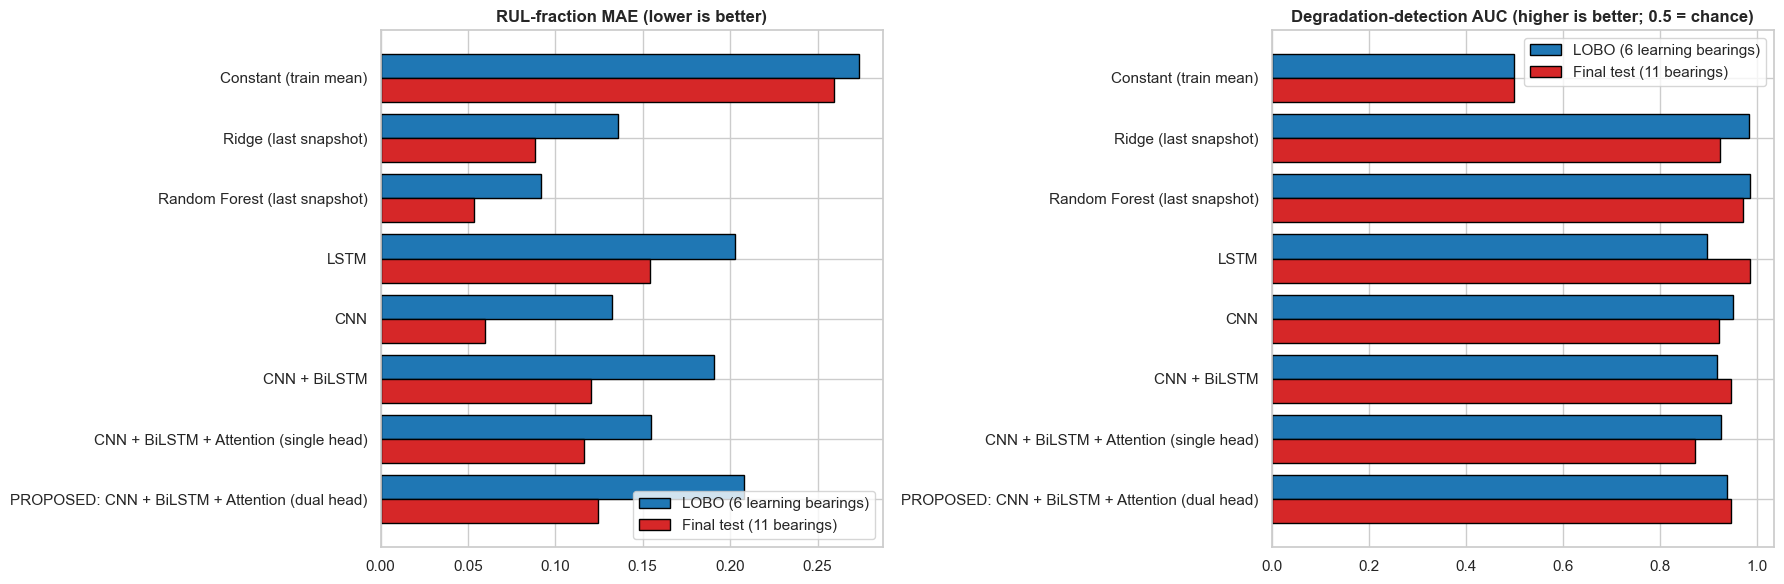

In [5]:
# ==============================================================================
# 4. FINAL MODEL: TRAIN ON ALL 6 LEARNING BEARINGS, SCORE ONCE ON THE 11 TEST BEARINGS
# ==============================================================================
sc_all = StandardScaler().fit(df.loc[df.bearing.isin(LEARN), F])
Xtr, ytr, str_, mtr = make_windows(LEARN, sc_all); Xte, yte, ste, mte = make_windows(TEST, sc_all)
wtr = class_weights(mtr.post_onset.values)
print(f"train windows {Xtr.shape} (post-onset {int(mtr.post_onset.sum())}) | test windows {Xte.shape} (post-onset {int(mte.post_onset.sum())})")
SEEDS = [42, 43, 44]; test_rows, preds, final_models = [], {}, {}
t0 = time.time()
for name in MODELS:
    det = name.startswith(('Constant', 'Ridge'))
    for sd in ([SEEDS[0]] if det else SEEDS):
        yh, pst, *mm = fit_predict(name, Xtr, ytr, str_, wtr, Xte, sd)
        r = metrics(yte, yh, ste, pst, mte); r.update({'Model': name, 'seed': sd}); test_rows.append(r); preds[(name, sd)] = (yh, pst)
        if name.startswith('PROPOSED') and mm: final_models[sd] = mm[0]
    print(f"  done: {name} ({time.time()-t0:.0f}s)")
df_test = pd.DataFrame(test_rows); df_test.to_csv(os.path.join(RESULTS_DIR, 'v2_test_all_runs.csv'), index=False)
tab_test = df_test.groupby('Model', sort=False)[num].agg(lambda s: f"{s.mean():.3f}" if len(s) == 1 else f"{s.mean():.3f} +/- {s.std():.3f}")
tab_test['Lead_min (median)'] = df_test.groupby('Model', sort=False)['Lead_min_median'].mean().round(1)
tab_test['Missed bearings'] = df_test.groupby('Model', sort=False)['Missed_bearings'].agg(lambda s: s.iloc[0] if len(s) == 1 else ' / '.join(s))
tab_test.to_csv(os.path.join(RESULTS_DIR, 'v2_test_summary.csv')); display(tab_test)

# ---- Figure V2: MAE and degradation-detection AUC, LOBO vs final test, with the constant baseline ----
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, (met, ttl) in zip(axes, [('MAE', 'RUL-fraction MAE (lower is better)'), ('AUC_degradation', 'Degradation-detection AUC (higher is better; 0.5 = chance)')]):
    lo = df_lobo.groupby('Model', sort=False)[met].mean(); te = df_test.groupby('Model', sort=False)[met].mean()
    yy = np.arange(len(MODELS)); ax.barh(yy - 0.2, lo.values, 0.4, label='LOBO (6 learning bearings)', color='#1f77b4', edgecolor='black')
    ax.barh(yy + 0.2, te.values, 0.4, label='Final test (11 bearings)', color='#d62728', edgecolor='black')
    ax.set_yticks(yy); ax.set_yticklabels(MODELS); ax.invert_yaxis(); ax.set_title(ttl, fontweight='bold'); ax.legend()
plt.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'figV2_model_comparison.png')); plt.show()


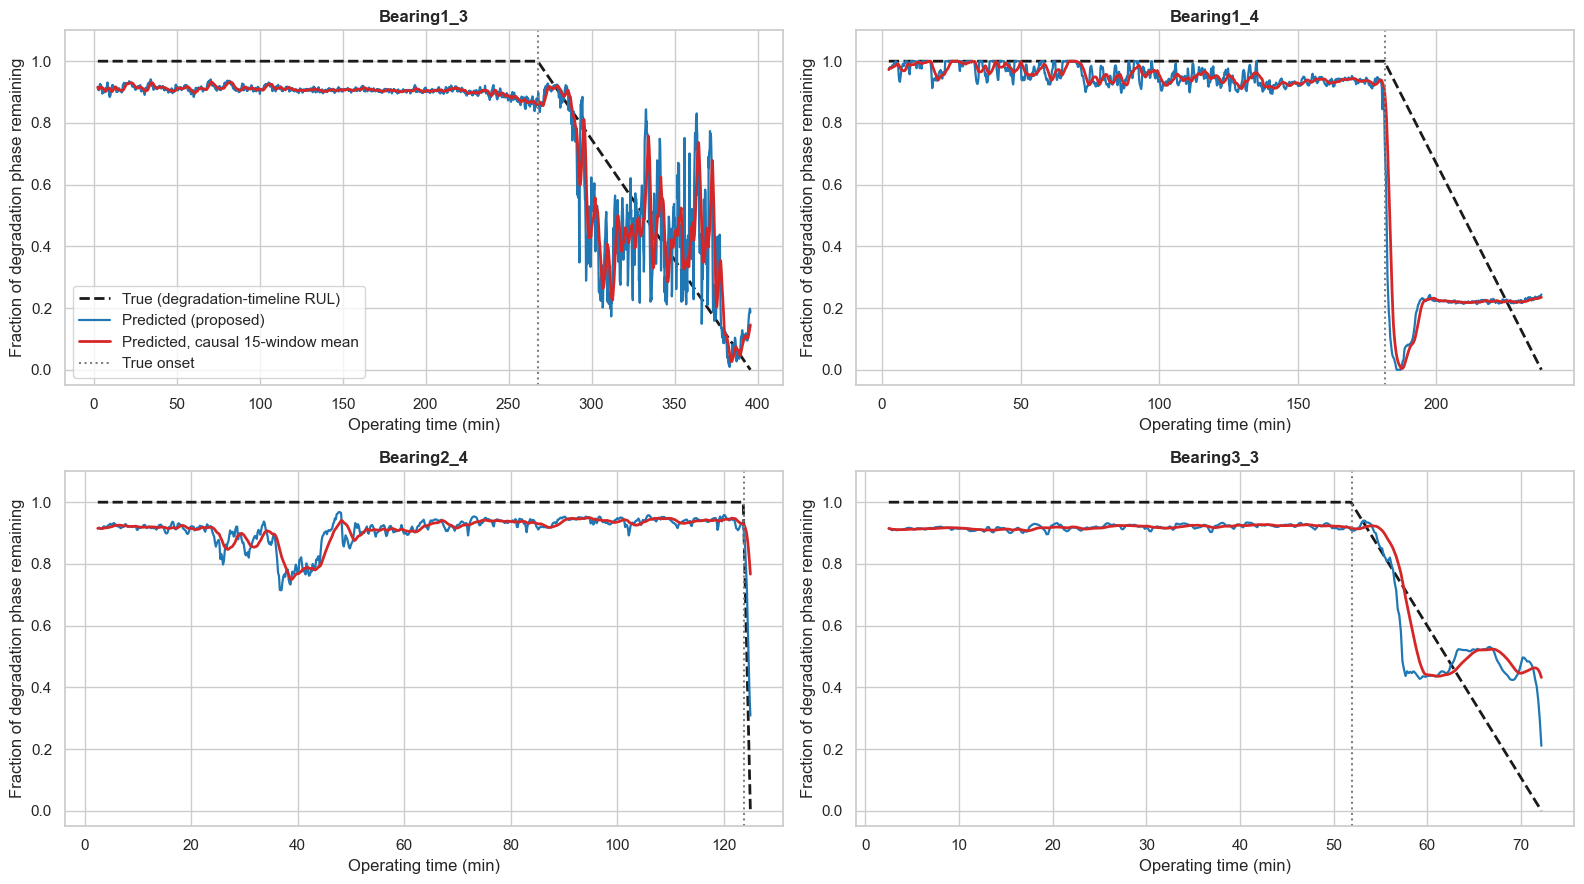

,degradation_windows,MAE,StageAcc,FalseAlarm_pct,Lead_min_median,Missed_bearings
Bearing,,,,,,
Bearing1_3,769,0.111,0.855,0.000,107.167,0/1
Bearing1_4,340,0.118,0.835,1.025,56.500,0/1
Bearing1_5,54,0.081,0.996,0.000,7.667,0/1
Bearing1_6,35,0.159,0.837,13.261,4.333,0/1
Bearing1_7,1051,0.168,0.488,12.070,159.833,0/1
Bearing2_3,8,0.085,0.997,0.000,1.000,0/1
Bearing2_4,8,0.089,0.993,0.000,0.167,0/1
Bearing2_5,10,0.096,0.835,15.617,NaN,1/1
Bearing2_6,13,0.066,0.988,0.000,1.500,0/1


In [6]:
# ==============================================================================
# 5. PREDICTED vs TRUE DEGRADATION-TIMELINE RUL ON HELD-OUT TEST BEARINGS (proposed model, seed 42)
# ==============================================================================
yh, pst = preds[('PROPOSED: CNN + BiLSTM + Attention (dual head)', 42)]
show = ['Bearing1_3', 'Bearing1_4', 'Bearing2_4', 'Bearing3_3']
fig, axes = plt.subplots(2, 2, figsize=(16, 9)); axes = axes.ravel()
for ax, q in zip(axes, show):
    m = (mte.bearing == q).values; t = mte.t_min.values[m]
    ax.plot(t, yte[m], 'k--', lw=2, label='True (degradation-timeline RUL)')
    ax.plot(t, yh[m], color='#1f77b4', lw=1.6, label='Predicted (proposed)')
    ax.plot(t, pd.Series(yh[m]).rolling(15, min_periods=1).mean().values, color='#d62728', lw=2, label='Predicted, causal 15-window mean')
    ax.axvline(t[mte.post_onset.values[m] == 1][0], color='gray', ls=':', label='True onset')
    ax.set_title(q, fontweight='bold'); ax.set_xlabel('Operating time (min)'); ax.set_ylabel('Fraction of degradation phase remaining'); ax.set_ylim(-0.05, 1.1)
axes[0].legend(loc='lower left')
plt.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'figV3_test_trajectories.png')); plt.show()

# per-bearing table for the proposed model
rows = []
for q in TEST:
    m = (mte.bearing == q).values; r = metrics(yte[m], yh[m], ste[m], pst[m], mte[m].reset_index(drop=True)); r['Bearing'] = q
    r['degradation_windows'] = int(mte.post_onset.values[m].sum()); rows.append(r)
tab_pb = pd.DataFrame(rows).set_index('Bearing')[['degradation_windows', 'MAE', 'StageAcc', 'FalseAlarm_pct', 'Lead_min_median', 'Missed_bearings']].round(3)
tab_pb.to_csv(os.path.join(RESULTS_DIR, 'v2_test_per_bearing_proposed.csv')); display(tab_pb)


---
# AUDIT OF THE V2 EXPERIMENT (verification cells)

Everything below only **checks** the experiment above; it does not tune anything and does not change any label, model or hyper-parameter. Offline vs online, in one table:

| Stage | Uses future samples? | Where |
|---|---|---|
| Feature extraction (30 features) | **No**: computed from the single 0.1 s snapshot itself | original notebook, verified in A3 |
| Model input window | **No**: the 16 most recent snapshots, ending at the current one | `make_windows`, verified in A3 |
| Scaler | No future *time*; fitted on training bearings only (never on held-out/test bearings) | A3, A4 |
| **Onset label** (offline) | **Yes**: median smoothing is centred, baseline is a quantile of the whole life, failure level is the max, onset is the final excursion | `find_onset`; labels only, never inputs |
| Training | Sees labels of training bearings only | A4 |
| Evaluation | Compares predictions with hindsight labels of held-out bearings | A2, A6 |


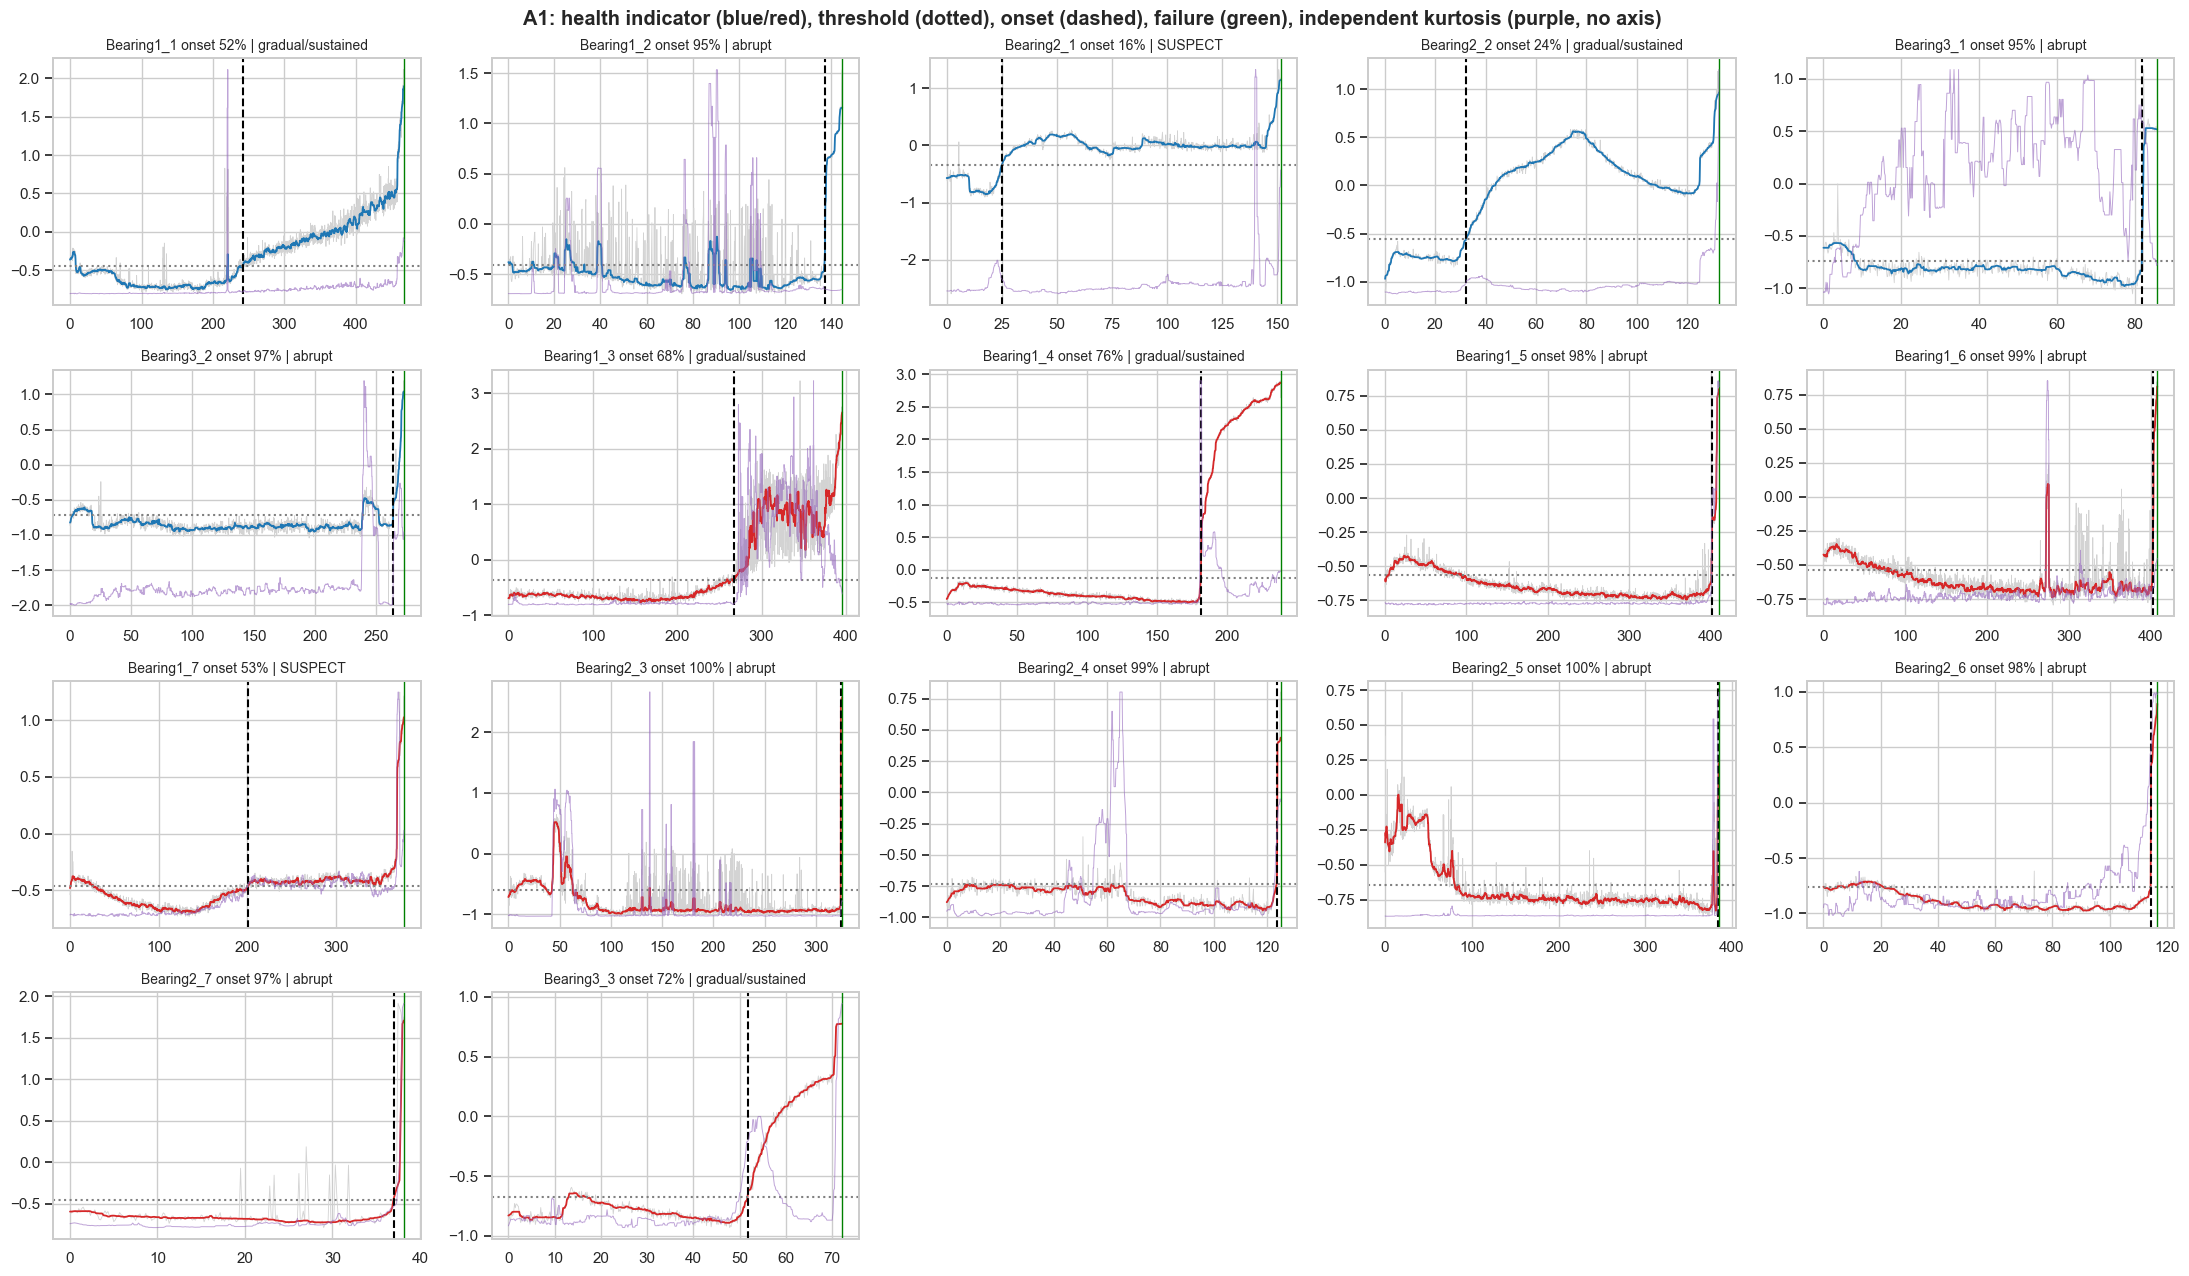

,Bearing,set,snapshots,failure_min,onset_idx,onset_min,onset_%life,phase_min,phase_snapshots,clamped,plateau_frac,spearman_HI_time,kurtosis_shift_z,verdict
0,Bearing1_1,learn,2803,467.0,1452,242.0,51.8,225.0,1350,False,0.46,0.99,18.1,gradual/sustained
1,Bearing1_2,learn,871,145.0,824,137.3,94.6,7.7,46,False,0.52,1.00,0.7,abrupt terminal failure
2,Bearing2_1,learn,911,151.7,150,25.0,16.5,126.7,760,False,0.84,0.05,2.1,SUSPECT step/plateau
3,Bearing2_2,learn,797,132.7,193,32.2,24.2,100.5,603,False,0.46,0.08,10.9,gradual/sustained
4,Bearing3_1,learn,515,85.7,491,81.8,95.3,3.8,23,False,0.81,0.15,-1.4,abrupt terminal failure
5,Bearing3_2,learn,1637,272.7,1584,264.0,96.8,8.7,52,False,0.19,1.00,12.6,abrupt terminal failure
6,Bearing1_3,test,2375,395.7,1605,267.5,67.6,128.2,769,False,0.37,0.53,107.7,gradual/sustained
7,Bearing1_4,test,1428,237.8,1087,181.2,76.1,56.7,340,False,0.30,1.00,21.0,gradual/sustained
8,Bearing1_5,test,2463,410.3,2408,401.3,97.8,9.0,54,False,0.65,0.92,183.6,abrupt terminal failure
9,Bearing1_6,test,2448,407.8,2412,402.0,98.5,5.8,35,False,0.50,1.00,6.1,abrupt terminal failure


Consistency assertions passed for all 17 bearings: vectorised == loop implementation; HI >= threshold from onset to failure; HI < threshold immediately before onset.
Clamped bearings (onset forced to n-2 to keep >=1 degradation step): []
Degradation windows per bearing available for evaluation are small for abrupt bearings (phase_snapshots column).


In [7]:
# ==============================================================================
# A2. ONSET LABEL VALIDITY: every bearing, exact numbers, consistency and transient/step check
# ==============================================================================
from scipy.stats import spearmanr

def onset_loop(g, frac=ONSET_FRAC):
    """Independent loop-based re-implementation of find_onset (cross-check of the vectorised code)."""
    hi = np.log(np.sqrt(g['horiz_rms'].values ** 2 + g['vert_rms'].values ** 2)); n = len(hi)
    h = np.array([np.median(hi[max(0, i - 7):min(n, i + 8)]) for i in range(n)])
    e = np.array([np.median(hi[max(0, i - 2):min(n, i + 3)]) for i in range(n)]).max()
    base = np.median(np.sort(h)[:int(0.3 * n)]); thr = base + frac * (e - base)
    last_below = max([i for i in range(n) if h[i] < thr], default=-1)
    return last_below + 1, h, thr

rows = []; fig, axes = plt.subplots(4, 5, figsize=(22, 13)); axes = axes.ravel()
for ax, bn in zip(axes, LEARN + TEST):
    g = df[df.bearing == bn].sort_values('snapshot_idx'); n = len(g)
    on_v, h, thr = find_onset(g); on_l, h2, thr2 = onset_loop(g)
    assert on_v == on_l and np.allclose(h, h2) and np.isclose(thr, thr2), f"{bn}: two implementations disagree"
    on = int(g.onset_idx.iloc[0]); assert on == min(on_v, n - 2)
    # consistency of the "final uninterrupted excursion" rule
    assert (h[on_v:] >= thr).all() and (on_v == 0 or h[on_v - 1] < thr), f"{bn}: rule violated"
    hp = h[on:]; m = max(3, int(0.9 * len(hp))); med = np.median(hp[:m])
    plateau = float((np.abs(hp[:m] - med) < 0.15).mean())
    rho = spearmanr(hp, np.arange(len(hp)))[0] if len(hp) > 3 else np.nan
    k = pd.Series(np.maximum(g.horiz_kurtosis.values, g.vert_kurtosis.values)).rolling(15, min_periods=1, center=True).median().values
    pre = k[:max(on, 3)]; mad = 1.4826 * np.median(np.abs(pre - np.median(pre))) + 1e-6
    kz = (np.median(k[on:]) - np.median(pre)) / mad                       # independent indicator, not used to define the onset
    phase_min = (n - 1 - on) * 10 / 60
    flag = 'SUSPECT step/plateau' if (n - 1 - on >= 360 and plateau >= 0.6) else ('abrupt terminal failure' if phase_min <= 20 else 'gradual/sustained')
    rows.append({'Bearing': bn, 'set': 'learn' if bn in LEARN else 'test', 'snapshots': n, 'failure_min': round((n - 1) * 10 / 60, 1),
                 'onset_idx': on, 'onset_min': round(on * 10 / 60, 1), 'onset_%life': round(100 * on / n, 1),
                 'phase_min': round(phase_min, 1), 'phase_snapshots': n - 1 - on, 'clamped': on_v != on,
                 'plateau_frac': round(plateau, 2), 'spearman_HI_time': round(rho, 2), 'kurtosis_shift_z': round(kz, 1), 'verdict': flag})
    t = g.t_min.values
    ax.plot(t, np.log(np.sqrt(g.horiz_rms.values ** 2 + g.vert_rms.values ** 2)), color='lightgray', lw=0.6, label='HI raw')
    ax.plot(t, h, color='#1f77b4' if bn in LEARN else '#d62728', lw=1.3, label='HI smoothed')
    ax.axhline(thr, color='gray', ls=':'); ax.axvline(t[on], color='black', ls='--'); ax.axvline(t[-1], color='green', lw=1)
    ax2 = ax.twinx(); ax2.plot(t, k, color='#9467bd', lw=0.7, alpha=0.6); ax2.set_yticks([])
    ax.set_title(f"{bn} onset {100*on/n:.0f}% | {flag.split()[0]}", fontsize=10)
for ax in axes[17:]: ax.axis('off')
fig.suptitle('A1: health indicator (blue/red), threshold (dotted), onset (dashed), failure (green), independent kurtosis (purple, no axis)', fontweight='bold')
plt.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'figA1_onset_audit_all_bearings.png')); plt.show()
audit_onset = pd.DataFrame(rows); audit_onset.to_csv(os.path.join(RESULTS_DIR, 'v2_audit_onset_table.csv'), index=False)
display(audit_onset)
print("Consistency assertions passed for all 17 bearings: vectorised == loop implementation; HI >= threshold from onset to failure; HI < threshold immediately before onset.")
print("Clamped bearings (onset forced to n-2 to keep >=1 degradation step):", audit_onset.loc[audit_onset.clamped, 'Bearing'].tolist())
print("Degradation windows per bearing available for evaluation are small for abrupt bearings (phase_snapshots column).")


In [8]:
# ==============================================================================
# A3. NO FUTURE INFORMATION IN THE MODEL INPUT (tests, not arguments)
# ==============================================================================
# (a) Input columns contain no labels, no time/RUL columns, no bearing metadata.
forbidden = {'snapshot_idx', 'operating_time_s', 'operating_time_m', 'actual_rul_s', 'actual_rul_m', 'capped_rul_s', 'capped_rul_m',
             'norm_rul', 'health_stage', 'y_deg', 'stage_deg', 'post_onset', 'onset_idx', 't_min', 'speed_rpm', 'load_n', 'condition_id', 'bearing'}
assert not forbidden & set(F) and all(c.startswith(('horiz_', 'vert_')) for c in F) and len(F) == 30
print("A3a passed: the 30 input columns are vibration features only.")

# (b) Causality test: cut a bearing's recording at snapshot `cut` (as if the machine were still running) and rebuild the windows.
#     The windows that exist in both versions must be IDENTICAL, and so must the model's predictions.
sc_chk = StandardScaler().fit(df.loc[df.bearing.isin(LEARN), F])
_df = df
try:
    for bn in ['Bearing1_1', 'Bearing1_3', 'Bearing2_4']:
        Xf, *_ = make_windows([bn], sc_chk); n = (df.bearing == bn).sum()
        for cut in [60, n // 2, n - 40]:
            df = _df[(_df.bearing != bn) | (_df.snapshot_idx < cut)]
            Xc, *_ = make_windows([bn], sc_chk); df = _df
            assert len(Xc) == cut - WINDOW + 1 and np.array_equal(Xc, Xf[:len(Xc)]), (bn, cut)
            if final_models:
                mm_ = final_models[42]; sc_all_ = sc_chk
                assert np.allclose(mm_.predict(Xc, verbose=0)['rul_output'], mm_.predict(Xf[:len(Xc)], verbose=0)['rul_output'], atol=1e-5)
finally:
    df = _df
print("A3b passed: windows/predictions at time t are unchanged when all data after t is deleted (3 bearings x 3 cut points).")

# (c) The last row of every window is the scaled feature vector of the CURRENT snapshot, and the label index is that snapshot.
Xw, yw, sw, mw = make_windows(['Bearing1_3'], sc_chk); g = df[df.bearing == 'Bearing1_3'].sort_values('snapshot_idx')
k = 500; assert np.allclose(Xw[k, -1], sc_chk.transform(g[F].iloc[[k + WINDOW - 1]])[0]) and mw.snapshot_idx.iloc[k] == k + WINDOW - 1
assert np.isclose(yw[k], g.y_deg.iloc[k + WINDOW - 1])
print("A3c passed: window k ends at snapshot k+15 and is labelled with that snapshot's target.")

# (d) Features are computed from ONE snapshot file only: recompute a few from the raw CSVs in isolation and compare.
def raw_feats(path, sep):
    d = pd.read_csv(path, sep=sep, header=None, usecols=[4, 5], dtype=np.float32).values; out = {}
    for pre, s in (('horiz', d[:, 0]), ('vert', d[:, 1])):
        c = s - s.mean(); var = (c ** 2).mean() + 1e-8
        out[f'{pre}_rms'] = np.sqrt((s ** 2).mean()); out[f'{pre}_kurtosis'] = (c ** 4).mean() / var ** 2 - 3
        f = np.abs(np.fft.rfft(c)); fr = np.fft.rfftfreq(len(s), 1 / 25600.0); out[f'{pre}_spec_centroid'] = (fr * f).sum() / (f.sum() + 1e-8)
    return out
rng_ = np.random.default_rng(0)
for bn in ['Bearing1_1', 'Bearing1_4', 'Bearing3_3']:
    sub = 'Learning_set' if bn in LEARN else 'Full_Test_Set'
    for i in rng_.choice((df.bearing == bn).sum(), 3, replace=False):
        p = os.path.join(BASE_DIR, 'ieee-phm-2012-data-challenge-dataset-master', sub, bn, f'acc_{i+1:05d}.csv')
        rf_ = raw_feats(p, ';' if bn == 'Bearing1_4' else ','); row = df[(df.bearing == bn) & (df.snapshot_idx == i)].iloc[0]
        for c, v in rf_.items(): assert np.isclose(v, row[c], rtol=2e-3, atol=1e-3), (bn, i, c, v, row[c])
print("A3d passed: 27 feature values recomputed from a single raw file each match the stored features (no cross-snapshot smoothing/state).")

# (e) The scaler statistics come from training bearings only.
assert np.allclose(sc_all.mean_, df.loc[df.bearing.isin(LEARN), F].mean().values, rtol=1e-4)
assert not np.allclose(sc_all.mean_, df[F].mean().values, rtol=1e-4)      # would be equal if test bearings had leaked in
print("A3e passed: final scaler == mean of the 6 learning bearings and differs from the all-bearing mean.")
print("\nCONCLUSION: inputs at time t depend only on snapshots <= t. Future information enters ONLY through the offline onset label.")


A3a passed: the 30 input columns are vibration features only.


A3b passed: windows/predictions at time t are unchanged when all data after t is deleted (3 bearings x 3 cut points).
A3c passed: window k ends at snapshot k+15 and is labelled with that snapshot's target.


A3d passed: 27 feature values recomputed from a single raw file each match the stored features (no cross-snapshot smoothing/state).
A3e passed: final scaler == mean of the 6 learning bearings and differs from the all-bearing mean.

CONCLUSION: inputs at time t depend only on snapshots <= t. Future information enters ONLY through the offline onset label.


In [9]:
# ==============================================================================
# A4. LOBO INTEGRITY + PER-FOLD RESULTS + WHY THE PROPOSED MODEL IS UNSTABLE
# ==============================================================================
rows = []; _df = df
try:
    for hold in LEARN:
        tr = [q for q in LEARN if q != hold]
        sc = StandardScaler().fit(df.loc[df.bearing.isin(tr), F])
        assert hold not in set(df.loc[df.bearing.isin(tr), 'bearing'])
        assert np.allclose(sc.mean_, df.loc[df.bearing.isin(tr), F].mean().values, rtol=1e-4)
        assert not np.allclose(sc.mean_, df.loc[df.bearing.isin(LEARN), F].mean().values, rtol=1e-4)
        Xc, yc, sc_c, mc = make_windows(tr, sc); wc = class_weights(mc.post_onset.values)
        # poison test: destroy the held-out bearing's features and labels; everything used for training must be unchanged
        dfp = _df.copy(); m = dfp.bearing == hold
        dfp.loc[m, F] = dfp.loc[m, F].values * 1e3 + np.random.default_rng(1).normal(size=(m.sum(), len(F))) * 7
        dfp.loc[m, ['y_deg', 'stage_deg', 'post_onset']] = 0
        df = dfp; scp = StandardScaler().fit(df.loc[df.bearing.isin(tr), F]); Xp, yp, sp, mp = make_windows(tr, scp); wp = class_weights(mp.post_onset.values); df = _df
        assert np.array_equal(Xp, Xc) and np.array_equal(yp, yc) and np.array_equal(sp, sc_c) and np.array_equal(wp, wc) and np.array_equal(scp.mean_, sc.mean_)
        rows.append(hold)
finally:
    df = _df
print("A4 passed for all 6 folds: held-out bearing not in training set; scaler, windows, labels and sample weights are bit-identical even when the")
print("held-out bearing's data is replaced by garbage. There is NO threshold/hyper-parameter/model selection in LOBO (all fixed in HPARAMS; no early stopping).")

# ---- per-fold results (all models) ----
for met in ['MAE', 'AUC_degradation']:
    print(f"\nPer-fold {met}"); display(df_lobo.pivot(index='Model', columns='Held-out', values=met).loc[MODELS].round(3))
info = df[df.bearing.isin(LEARN)].groupby('bearing').agg(onset_pct=('onset_idx', lambda s: 0), n=('snapshot_idx', 'size'), post=('post_onset', 'sum'))
info['onset_pct'] = (100 * df[df.bearing.isin(LEARN)].groupby('bearing').onset_idx.first() / info.n).round(1)
print("\nHeld-out bearing characteristics (degradation windows are what AUC is computed on):"); display(info)

# ---- seed vs fold: is the instability the model (seed) or the bearing (fold)? extra LOBO seeds for CNN and Proposed ----
extra = []; t0 = time.time()
for hold in LEARN:
    tr = [q for q in LEARN if q != hold]; sc = StandardScaler().fit(df.loc[df.bearing.isin(tr), F])
    Xtr_, ytr_, str__, mtr_ = make_windows(tr, sc); Xte_, yte_, ste_, mte_ = make_windows([hold], sc); w_ = class_weights(mtr_.post_onset.values)
    for name in ['CNN', 'PROPOSED: CNN + BiLSTM + Attention (dual head)']:
        for sd in [43, 44]:
            yh_, pst_, *_ = fit_predict(name, Xtr_, ytr_, str__, w_, Xte_, sd)
            r = metrics(yte_, yh_, ste_, pst_, mte_); r.update({'Model': name, 'Held-out': hold, 'seed': sd}); extra.append(r)
    print(f"  extra-seed fold {hold} done ({time.time()-t0:.0f}s)")
d0 = df_lobo[df_lobo.Model.isin(['CNN', 'PROPOSED: CNN + BiLSTM + Attention (dual head)'])].assign(seed=42)
seedfold = pd.concat([d0, pd.DataFrame(extra)]); seedfold.to_csv(os.path.join(RESULTS_DIR, 'v2_audit_lobo_seeds.csv'), index=False)
for name in ['CNN', 'PROPOSED: CNN + BiLSTM + Attention (dual head)']:
    print(f"\n{name}: AUC by fold (rows) x seed (columns)")
    display(seedfold[seedfold.Model == name].pivot(index='Held-out', columns='seed', values='AUC_degradation').round(3))
    pv = seedfold[seedfold.Model == name].pivot(index='Held-out', columns='seed', values='AUC_degradation')
    print(f"   std across FOLDS (mean over seeds) = {pv.mean(1).std():.3f} | std across SEEDS (mean over folds) = {pv.mean(0).std():.3f} | within-fold seed std (avg) = {pv.std(1).mean():.3f}")


A4 passed for all 6 folds: held-out bearing not in training set; scaler, windows, labels and sample weights are bit-identical even when the
held-out bearing's data is replaced by garbage. There is NO threshold/hyper-parameter/model selection in LOBO (all fixed in HPARAMS; no early stopping).

Per-fold MAE


Held-out,Bearing1_1,Bearing1_2,Bearing2_1,Bearing2_2,Bearing3_1,Bearing3_2
Model,,,,,,
Constant (train mean),0.281,0.254,0.303,0.298,0.254,0.253
Ridge (last snapshot),0.099,0.274,0.257,0.134,0.035,0.015
Random Forest (last snapshot),0.103,0.033,0.209,0.173,0.025,0.006
LSTM,0.159,0.335,0.280,0.195,0.128,0.120
CNN,0.211,0.153,0.216,0.178,0.013,0.024
CNN + BiLSTM,0.204,0.282,0.228,0.181,0.117,0.134
CNN + BiLSTM + Attention (single head),0.135,0.198,0.231,0.183,0.088,0.092
PROPOSED: CNN + BiLSTM + Attention (dual head),0.195,0.311,0.271,0.195,0.105,0.169



Per-fold AUC_degradation


Held-out,Bearing1_1,Bearing1_2,Bearing2_1,Bearing2_2,Bearing3_1,Bearing3_2
Model,,,,,,
Constant (train mean),0.500,0.500,0.500,0.500,0.500,0.500
Ridge (last snapshot),0.978,0.974,0.991,1.000,0.960,0.999
Random Forest (last snapshot),0.998,1.000,0.994,0.997,0.993,0.934
LSTM,0.842,0.958,1.000,0.956,0.956,0.669
CNN,0.865,1.000,0.998,0.999,1.000,0.847
CNN + BiLSTM,0.750,0.989,1.000,0.955,0.993,0.823
CNN + BiLSTM + Attention (single head),0.999,0.991,1.000,0.999,0.826,0.751
PROPOSED: CNN + BiLSTM + Attention (dual head),0.802,0.942,0.999,0.964,0.951,0.971



Held-out bearing characteristics (degradation windows are what AUC is computed on):


...

  extra-seed fold Bearing3_2 done (1059s)

CNN: AUC by fold (rows) x seed (columns)


seed,42,43,44
Held-out,,,
Bearing1_1,0.865,0.722,0.934
Bearing1_2,1.000,1.000,0.989
Bearing2_1,0.998,1.000,1.000
Bearing2_2,0.999,1.000,0.936
Bearing3_1,1.000,0.758,0.930
Bearing3_2,0.847,0.955,0.989


   std across FOLDS (mean over seeds) = 0.063 | std across SEEDS (mean over folds) = 0.030 | within-fold seed std (avg) = 0.059

PROPOSED: CNN + BiLSTM + Attention (dual head): AUC by fold (rows) x seed (columns)


seed,42,43,44
Held-out,,,
Bearing1_1,0.802,0.933,0.770
Bearing1_2,0.942,0.896,0.912
Bearing2_1,0.999,0.999,1.000
Bearing2_2,0.964,0.956,0.943
Bearing3_1,0.951,0.984,0.995
Bearing3_2,0.971,0.998,0.997


   std across FOLDS (mean over seeds) = 0.061 | std across SEEDS (mean over folds) = 0.014 | within-fold seed std (avg) = 0.027


In [10]:
# ==============================================================================
# A5. BASELINE FAIRNESS
# ==============================================================================
print("All models in section 4 were trained on the SAME arrays: Xtr", Xtr.shape, "Xte", Xte.shape, "| same make_windows call, same y/stage targets, same sample weights.")
cfg = pd.DataFrame([
    ['Constant', 'none (weighted mean of training targets)', 'same weights', 'n/a', 'thresholds 0.90/0.35 on y-hat'],
    ['Ridge', 'LAST snapshot only (30 features)', 'same weights', 'alpha=1.0', 'thresholds 0.90/0.35 on y-hat'],
    ['Random Forest', 'LAST snapshot only (30 features)', 'same weights', '200 trees, min_leaf=5 (chosen before v2 in an earlier experiment on the OLD target that scored test bearings)', 'thresholds 0.90/0.35 on y-hat'],
    ['CNN', 'full 16x30 window', 'same weights', '25 epochs fixed, no tuning', 'thresholds 0.90/0.35 on y-hat'],
    ['Proposed', 'full 16x30 window', 'same weights', '25 epochs fixed, no tuning', 'its own classification head (different rule!)'],
], columns=['Model', 'Input', 'Weights', 'Hyper-parameters', 'Stage / alarm source'])
display(cfg)

# (1) Symmetric alarm rule: score EVERY model's alarms from its regression output with the same thresholds.
sym = []
for (name, sd), (yh_, pst_) in preds.items():
    r = metrics(yte, yh_, ste, y_to_stage(yh_), mte); r.update({'Model': name, 'seed': sd}); sym.append(r)
sym = pd.DataFrame(sym); tab_sym = sym.groupby('Model', sort=False)[['MAE', 'AUC_degradation', 'StageAcc', 'MacroF1', 'FalseAlarm_pct']].mean().round(3)
print("\nTest set, alarms derived from y-hat for ALL models (proposed's classification head ignored):"); display(tab_sym)

# (2) Does Random Forest profit from seeing only the last snapshot, or from being a forest? Give it the full window too.
rf_flat = RandomForestRegressor(200, min_samples_leaf=5, n_jobs=-1, random_state=SEED).fit(Xtr.reshape(len(Xtr), -1), ytr, sample_weight=wtr)
yh_f = np.clip(rf_flat.predict(Xte.reshape(len(Xte), -1)), 0, 1); r = metrics(yte, yh_f, ste, y_to_stage(yh_f), mte)
print(f"RF on the full flattened 16x30 window: MAE {r['MAE']:.3f} | AUC {r['AUC_degradation']:.3f} | false alarms {r['FalseAlarm_pct']:.1f}%  (RF last snapshot: see table above)")
print("\nAdvantages that remain and must be stated: (i) RF is an ensemble of 200 trees, the NNs are single networks (mean of 3 seeds reported);")
print("(ii) trees are insensitive to the heavy-tailed feature scale; (iii) RF hyper-parameters came from an earlier experiment that touched test bearings (see A6).")


All models in section 4 were trained on the SAME arrays: Xtr (7444, 16, 30) Xte (17190, 16, 30) | same make_windows call, same y/stage targets, same sample weights.


,Model,Input,Weights,Hyper-parameters,Stage / alarm source
0,Constant,none (weighted mean of training targets),same weights,n/a,thresholds 0.90/0.35 on y-hat
1,Ridge,LAST snapshot only (30 features),same weights,alpha=1.0,thresholds 0.90/0.35 on y-hat
2,Random Forest,LAST snapshot only (30 features),same weights,"200 trees, min_leaf=5 (chosen before v2 in an ...",thresholds 0.90/0.35 on y-hat
3,CNN,full 16x30 window,same weights,"25 epochs fixed, no tuning",thresholds 0.90/0.35 on y-hat
4,Proposed,full 16x30 window,same weights,"25 epochs fixed, no tuning",its own classification head (different rule!)



Test set, alarms derived from y-hat for ALL models (proposed's classification head ignored):


,MAE,AUC_degradation,StageAcc,MacroF1,FalseAlarm_pct
Model,,,,,
Constant (train mean),0.259,0.500,0.091,0.056,99.723
Ridge (last snapshot),0.088,0.925,0.813,0.572,9.237
Random Forest (last snapshot),0.054,0.973,0.894,0.628,0.843
LSTM,0.154,0.987,0.093,0.199,97.521
CNN,0.060,0.922,0.915,0.660,1.505
CNN + BiLSTM,0.120,0.946,0.657,0.477,29.203
CNN + BiLSTM + Attention (single head),0.116,0.874,0.816,0.547,10.457
PROPOSED: CNN + BiLSTM + Attention (dual head),0.124,0.947,0.568,0.445,38.333


RF on the full flattened 16x30 window: MAE 0.062 | AUC 0.942 | false alarms 2.3%  (RF last snapshot: see table above)

Advantages that remain and must be stated: (i) RF is an ensemble of 200 trees, the NNs are single networks (mean of 3 seeds reported);
(ii) trees are insensitive to the heavy-tailed feature scale; (iii) RF hyper-parameters came from an earlier experiment that touched test bearings (see A6).


In [11]:
# ==============================================================================
# A6. TEST-SET INTEGRITY: what did (and did not) touch the 11 test bearings + onset-rule sensitivity
# ==============================================================================
integrity = pd.DataFrame([
    ['Onset rule design (smoothing 15/5, quantile 0.30, "final excursion", 10%)', 'YES, partially', 'While designing the rule I inspected health-indicator curves and onset fractions of ALL 17 bearings, including test bearings, and tried several rule variants. The 10% value was fixed before any v2 model was trained, but the rule was not designed blind.'],
    ['Decision to abandon the global-cap target', 'YES', 'Motivated by poor results of the OLD target on the test bearings (constant baseline beat the model).'],
    ['RF hyper-parameters, 25 epochs, up-weighting cap 10, alarm rule of 3 windows', 'Partly', 'RF settings and the fixed-epoch idea come from earlier experiments that scored test bearings on the OLD target; they were not re-tuned in v2. Weight cap and alarm rule were set once without looking at v2 test output.'],
    ['Architecture (CNN-BiLSTM-Attention, window 16)', 'No', 'Inherited from the original notebook, which used bearing-level validation.'],
    ['Early stopping / model selection in v2', 'No', 'None exists: fixed epochs, no checkpoint selection, every model reported.'],
    ['Threshold selection for alarms (0.90 / 0.35, 3 windows)', 'No test tuning', 'Fixed a priori from the label definition; not tuned on any results.'],
    ['Number of times the v2 test set was scored', '1 (plus this audit re-run)', 'No model or setting was changed after seeing v2 test numbers.'],
], columns=['Item', 'Test bearings influenced it?', 'Detail'])
pd.set_option('display.max_colwidth', 200); display(integrity); integrity.to_csv(os.path.join(RESULTS_DIR, 'v2_audit_test_integrity.csv'), index=False)

# ---- Robustness (NOT optimisation): does the ranking Constant >> others, RF/CNN better than Proposed survive other onset thresholds? ----
def build_labels(frac):
    out = []
    for bn, g in df.groupby('bearing'):
        g = g.sort_values('snapshot_idx'); n = len(g); on, _, _ = find_onset(g, frac); on = min(on, n - 2); idx = np.arange(n)
        y = np.where(idx <= on, 1.0, (n - 1 - idx) / (n - 1 - on)); st = np.where(idx <= on, 0, np.where(y > STAGE_T, 1, 2))
        out.append(pd.DataFrame({'bearing': bn, 'snapshot_idx': idx, 'y_deg2': y, 'stage2': st, 'post2': (idx > on).astype(int), 'onset2': on}))
    return pd.concat(out)
_df = df; sens = []
try:
    for frac in [0.05, 0.10, 0.20]:
        L = build_labels(frac); d2 = _df.merge(L, on=['bearing', 'snapshot_idx'])
        df = d2.assign(y_deg=d2.y_deg2, stage_deg=d2.stage2, post_onset=d2.post2)
        Xa, ya, sa, ma = make_windows(LEARN, sc_all); Xb, yb, sb, mb = make_windows(TEST, sc_all); wa = class_weights(ma.post_onset.values)
        for name in ['Constant (train mean)', 'Random Forest (last snapshot)', 'CNN', 'PROPOSED: CNN + BiLSTM + Attention (dual head)']:
            yh_, pst_, *_ = fit_predict(name, Xa, ya, sa, wa, Xb, SEED); r = metrics(yb, yh_, sb, y_to_stage(yh_), mb)
            sens.append({'onset_fraction': frac, 'Model': name, 'MAE': r['MAE'], 'AUC': r['AUC_degradation'], 'FalseAlarm_%': r['FalseAlarm_pct'], 'test_degradation_windows': int(mb.post_onset.sum())})
finally:
    df = _df
sens = pd.DataFrame(sens); sens.to_csv(os.path.join(RESULTS_DIR, 'v2_audit_onset_sensitivity.csv'), index=False)
print("\nSensitivity to the onset fraction (seed 42; alarms from y-hat; reported, not used to choose anything):")
display(sens.pivot(index='Model', columns='onset_fraction', values='MAE').round(3)); display(sens.pivot(index='Model', columns='onset_fraction', values='AUC').round(3))


,Item,Test bearings influenced it?,Detail
0,"Onset rule design (smoothing 15/5, quantile 0.30, ""final excursion"", 10%)","YES, partially","While designing the rule I inspected health-indicator curves and onset fractions of ALL 17 bearings, including test bearings, and tried several rule variants. The 10% value was fixed before any v2..."
1,Decision to abandon the global-cap target,YES,Motivated by poor results of the OLD target on the test bearings (constant baseline beat the model).
2,"RF hyper-parameters, 25 epochs, up-weighting cap 10, alarm rule of 3 windows",Partly,RF settings and the fixed-epoch idea come from earlier experiments that scored test bearings on the OLD target; they were not re-tuned in v2. Weight cap and alarm rule were set once without lookin...
3,"Architecture (CNN-BiLSTM-Attention, window 16)",No,"Inherited from the original notebook, which used bearing-level validation."
4,Early stopping / model selection in v2,No,"None exists: fixed epochs, no checkpoint selection, every model reported."
5,"Threshold selection for alarms (0.90 / 0.35, 3 windows)",No test tuning,Fixed a priori from the label definition; not tuned on any results.
6,Number of times the v2 test set was scored,1 (plus this audit re-run),No model or setting was changed after seeing v2 test numbers.



Sensitivity to the onset fraction (seed 42; alarms from y-hat; reported, not used to choose anything):


onset_fraction,0.05,0.10,0.20
Model,,,
CNN,0.054,0.053,0.060
Constant (train mean),0.261,0.259,0.256
PROPOSED: CNN + BiLSTM + Attention (dual head),0.108,0.114,0.119
Random Forest (last snapshot),0.057,0.054,0.027


onset_fraction,0.05,0.10,0.20
Model,,,
CNN,0.952,0.960,0.921
Constant (train mean),0.500,0.500,0.500
PROPOSED: CNN + BiLSTM + Attention (dual head),0.886,0.963,0.970
Random Forest (last snapshot),0.962,0.973,0.967


In [12]:
# ==============================================================================
# A7. WHAT THE RUL METRIC MEASURES + ADDITIONAL METRICS
# ==============================================================================
# y-hat and y are in [0,1].  y = 1 before the bearing's degradation onset t0;  y(t) = (T_fail - t)/(T_fail - t0) after it.
# MAE = mean over ALL windows of |y - y-hat|.  It mixes two things: (i) calibration on healthy windows (true y = 1) and
# (ii) tracking of the remaining fraction of the degradation phase.  Because most windows are healthy, (i) dominates.
sel = ['Constant (train mean)', 'Random Forest (last snapshot)', 'CNN', 'PROPOSED: CNN + BiLSTM + Attention (dual head)']
rows = []
for name in sel:
    for sd in sorted({s for (n_, s) in preds if n_ == name}):
        yh_ = preds[(name, sd)][0]; post = mte.post_onset.values == 1
        per_b = [np.abs(yte[(mte.bearing == q).values] - yh_[(mte.bearing == q).values]).mean() for q in TEST]
        post_b = [np.abs(yte[((mte.bearing == q).values) & post] - yh_[((mte.bearing == q).values) & post]).mean() for q in TEST]
        rows.append({'Model': name, 'seed': sd, 'MAE_all_windows': np.abs(yte - yh_).mean(), 'MAE_pre_onset(healthy)': np.abs(yte - yh_)[~post].mean(),
                     'MAE_degradation_phase': np.abs(yte - yh_)[post].mean(), 'MAE_per_bearing_macro': np.mean(per_b),
                     'MAE_degradation_macro_per_bearing': np.mean(post_b)})
mt = pd.DataFrame(rows).groupby('Model', sort=False).mean(numeric_only=True).drop(columns='seed')
mt['Skill_vs_constant_(all)'] = 1 - mt['MAE_all_windows'] / mt.loc['Constant (train mean)', 'MAE_all_windows']
mt['Skill_vs_constant_(degradation)'] = 1 - mt['MAE_degradation_phase'] / mt.loc['Constant (train mean)', 'MAE_degradation_phase']
mt.round(3).to_csv(os.path.join(RESULTS_DIR, 'v2_audit_extra_metrics.csv')); display(mt.round(3))
pb = pd.DataFrame({name: [np.mean([np.abs(yte[(mte.bearing == q).values & (mte.post_onset.values == 1)] - preds[(name, sd)][0][(mte.bearing == q).values & (mte.post_onset.values == 1)]).mean()
                                     for sd in sorted({s for (n_, s) in preds if n_ == name})]) for q in TEST] for name in sel}, index=TEST)
pb.insert(0, 'degradation_windows', [int(((mte.bearing == q) & (mte.post_onset == 1)).sum()) for q in TEST])
print("Degradation-phase MAE per test bearing (mean over seeds):"); display(pb.round(3))
print("\nAPPROPRIATENESS: the PHM-2012 challenge scores the predicted RUL in MINUTES at ONE truncation time per test bearing with an asymmetric %-error score.")
print("This fraction metric is neither, so it is NOT comparable to challenge/leaderboard numbers. Do not convert to minutes: the phase length T_fail - t0 is not known at prediction time.")


,MAE_all_windows,MAE_pre_onset(healthy),MAE_degradation_phase,MAE_per_bearing_macro,MAE_degradation_macro_per_bearing,Skill_vs_constant_(all),Skill_vs_constant_(degradation)
Model,,,,,,,
Constant (train mean),0.259,0.251,0.313,0.259,0.327,0.000,0.000
Random Forest (last snapshot),0.054,0.010,0.322,0.047,0.283,0.793,-0.028
CNN,0.060,0.022,0.293,0.056,0.264,0.769,0.066
PROPOSED: CNN + BiLSTM + Attention (dual head),0.124,0.100,0.275,0.121,0.254,0.520,0.122


Degradation-phase MAE per test bearing (mean over seeds):


,degradation_windows,Constant (train mean),Random Forest (last snapshot),CNN,PROPOSED: CNN + BiLSTM + Attention (dual head)
Bearing1_3,769,0.313,0.172,0.146,0.179
Bearing1_4,340,0.313,0.459,0.603,0.354
Bearing1_5,54,0.317,0.258,0.147,0.105
Bearing1_6,35,0.320,0.188,0.169,0.155
Bearing1_7,1051,0.312,0.409,0.325,0.343
Bearing2_3,8,0.343,0.403,0.293,0.362
Bearing2_4,8,0.343,0.195,0.219,0.265
Bearing2_5,10,0.340,0.381,0.522,0.465
Bearing2_6,13,0.333,0.200,0.098,0.143
Bearing2_7,7,0.352,0.223,0.196,0.240



APPROPRIATENESS: the PHM-2012 challenge scores the predicted RUL in MINUTES at ONE truncation time per test bearing with an asymmetric %-error score.
This fraction metric is neither, so it is NOT comparable to challenge/leaderboard numbers. Do not convert to minutes: the phase length T_fail - t0 is not known at prediction time.


In [13]:
# ==============================================================================
# A8. EARLY-WARNING PERFORMANCE PER BEARING (alarm = predicted y-hat below 0.90 for 3 consecutive windows; same rule for every model)
# ==============================================================================
def warning_table(name, sd):
    yh_ = preds[(name, sd)][0]; ps = y_to_stage(yh_); out = []
    for q in TEST:
        m = (mte.bearing == q).values; alarm = sustained(ps[m] >= 1); po = mte.post_onset.values[m]; t = mte.t_min.values[m]
        pre_alarm = alarm[po == 0]; ep = int(((pre_alarm[1:].astype(int) - pre_alarm[:-1].astype(int)) == 1).sum() + (pre_alarm[:1].sum()))
        hit = np.where(alarm & (po == 1))[0]; phase = t[-1] - t[po == 1][0]
        first_pre = np.where(alarm & (po == 0))[0]
        out.append({'Bearing': q, 'phase_min': round(phase, 1), 'detected': bool(len(hit)), 'lead_min': round(t[-1] - t[hit[0]], 1) if len(hit) else np.nan,
                    'lead_%_of_phase': round(100 * (t[-1] - t[hit[0]]) / phase, 0) if len(hit) else np.nan,
                    'false_alarm_%_healthy': round(100 * pre_alarm.mean(), 1), 'false_alarm_episodes': ep,
                    'first_alarm_before_onset': bool(len(first_pre))})
    return pd.DataFrame(out).set_index('Bearing')
allw = {}
for name in sel[1:]:
    print(f"\n=== {name} (seed 42) ==="); wt = warning_table(name, 42); display(wt); allw[name] = wt; wt.to_csv(os.path.join(RESULTS_DIR, f"v2_audit_warning_{name.split(':')[0].split(' ')[0].lower()}.csv"))
det = pd.DataFrame({name: [sum(warning_table(name, sd).detected.sum() for sd in sorted({s for (n_, s) in preds if n_ == name}))] for name in sel[1:]}, index=['detected bearings, summed over seeds'])
nseeds = {name: len({s for (n_, s) in preds if n_ == name}) for name in sel[1:]}; print("\nDetected degradation phases out of 11 x seeds:", {k: f"{int(det[k].iloc[0])}/{11*nseeds[k]}" for k in det})
print("Interpretation guide: bearings with phase_min <= ~20 min fail abruptly; any lead time there is minutes, not a maintenance window.")



=== Random Forest (last snapshot) (seed 42) ===


,phase_min,detected,lead_min,lead_%_of_phase,false_alarm_%_healthy,false_alarm_episodes,first_alarm_before_onset
Bearing,,,,,,,
Bearing1_3,128.0,True,126.2,99.0,0.0,0,False
Bearing1_4,56.5,True,56.3,100.0,0.0,0,False
Bearing1_5,8.8,True,2.8,32.0,0.0,0,False
Bearing1_6,5.7,True,4.3,76.0,0.8,1,True
Bearing1_7,175.0,True,27.8,16.0,0.0,0,False
Bearing2_3,1.2,True,1.0,86.0,1.9,3,True
Bearing2_4,1.2,True,0.8,71.0,0.0,0,False
Bearing2_5,1.5,False,NaN,NaN,6.7,20,True
Bearing2_6,2.0,True,1.8,92.0,0.0,0,False



=== CNN (seed 42) ===


,phase_min,detected,lead_min,lead_%_of_phase,false_alarm_%_healthy,false_alarm_episodes,first_alarm_before_onset
Bearing,,,,,,,
Bearing1_3,128.0,True,108.8,85.0,0.0,0,False
Bearing1_4,56.5,True,55.8,99.0,0.0,0,False
Bearing1_5,8.8,True,6.2,70.0,0.0,0,False
Bearing1_6,5.7,True,3.8,68.0,1.1,1,True
Bearing1_7,175.0,True,175.0,100.0,3.9,1,True
Bearing2_3,1.2,True,0.8,71.0,2.6,8,True
Bearing2_4,1.2,True,0.3,29.0,1.6,1,True
Bearing2_5,1.5,False,NaN,NaN,11.1,3,True
Bearing2_6,2.0,True,1.5,75.0,0.0,0,False



=== PROPOSED: CNN + BiLSTM + Attention (dual head) (seed 42) ===


,phase_min,detected,lead_min,lead_%_of_phase,false_alarm_%_healthy,false_alarm_episodes,first_alarm_before_onset
Bearing,,,,,,,
Bearing1_3,128.0,True,128.0,100.0,13.3,22,True
Bearing1_4,56.5,True,56.5,100.0,0.4,2,True
Bearing1_5,8.8,True,7.7,87.0,0.1,3,True
Bearing1_6,5.7,True,5.7,100.0,46.7,62,True
Bearing1_7,175.0,True,175.0,100.0,17.2,22,True
Bearing2_3,1.2,True,1.0,86.0,4.0,32,True
Bearing2_4,1.2,True,0.8,71.0,15.4,6,True
Bearing2_5,1.5,True,0.7,44.0,24.4,38,True
Bearing2_6,2.0,True,1.7,83.0,0.0,0,False



Detected degradation phases out of 11 x seeds:

 {'Random Forest (last snapshot)': '30/33', 'CNN': '30/33', 'PROPOSED: CNN + BiLSTM + Attention (dual head)': '32/33'}
Interpretation guide: bearings with phase_min <= ~20 min fail abruptly; any lead time there is minutes, not a maintenance window.


Attention weight on the 4 newest steps (uniform = 0.25) and entropy (uniform = 2.773), per test bearing with both phases, mean over seeds:


,last4_pre,last4_post,entropy_pre,entropy_post
Bearing,,,,
Bearing1_3,0.275,0.176,2.703,2.620
Bearing1_4,0.280,0.232,2.665,2.713
Bearing1_5,0.292,0.258,2.690,2.607
Bearing1_6,0.278,0.310,2.651,2.554
Bearing1_7,0.294,0.252,2.684,2.682
Bearing2_3,0.314,0.475,2.565,2.101
Bearing2_4,0.265,0.300,2.699,2.629
Bearing2_5,0.287,0.548,2.578,2.397
Bearing2_6,0.258,0.346,2.709,2.580


Paired difference (post-onset minus pre-onset) in newest-4-step weight: mean +0.032; positive in 6/11 bearings

Functional importance of the attention layer (same trained network, attention replaced by uniform weights):


,seed,MAE_with_attention,MAE_uniform_weights,"corr(pred_att, pred_uniform)",mean|pred_att - pred_uniform|
0,42,0.1139,0.116,0.9918,0.0136
1,43,0.1453,0.149,0.9954,0.0121
2,44,0.1141,0.121,0.9965,0.0113



Proposed (seed 42) baseline: MAE 0.114, AUC 0.963 | RF baseline: MAE 0.054, AUC 0.973


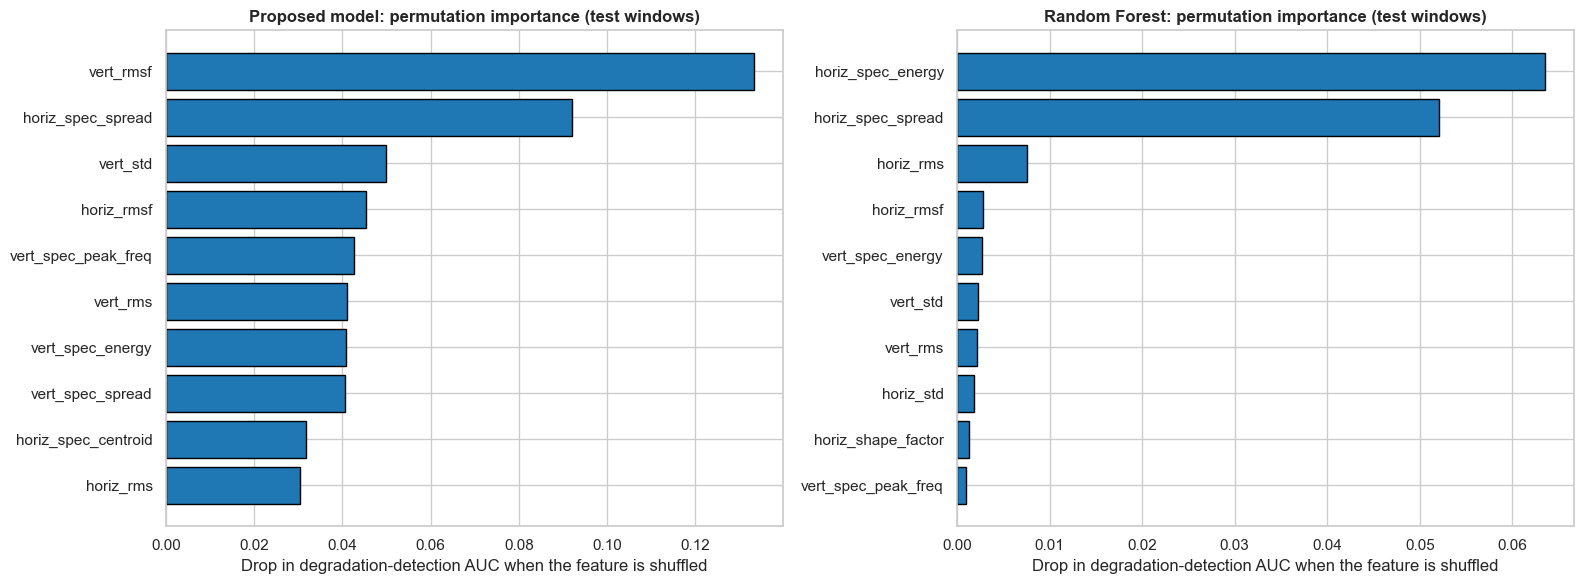

Top-5 features, proposed: vert_rmsf (dAUC +0.133), horiz_spec_spread (dAUC +0.092), vert_std (dAUC +0.050), horiz_rmsf (dAUC +0.045), vert_spec_peak_freq (dAUC +0.043)
Top-5 features, RF      : horiz_spec_energy (dAUC +0.063), horiz_spec_spread (dAUC +0.052), horiz_rms (dAUC +0.008), horiz_rmsf (dAUC +0.003), vert_spec_energy (dAUC +0.003)


In [14]:
# ==============================================================================
# A9. EXPLAINABILITY AUDIT (test windows, trained models only; labels used for scoring, never for fitting)
# ==============================================================================
post_mask = mte.post_onset.values == 1
rows = []; abl = []
for sd, m_ in final_models.items():
    attn_m = Model(m_.input, m_.get_layer('temporal_attention').output[1]); A = attn_m.predict(Xte, batch_size=512, verbose=0)[:, :, 0]
    ent = -(A * np.log(A + 1e-12)).sum(1); last4 = A[:, -4:].sum(1)
    for q in TEST:
        b_ = (mte.bearing == q).values
        if (b_ & post_mask).any() and (b_ & ~post_mask).any():
            rows.append({'seed': sd, 'Bearing': q, 'last4_pre': last4[b_ & ~post_mask].mean(), 'last4_post': last4[b_ & post_mask].mean(),
                         'entropy_pre': ent[b_ & ~post_mask].mean(), 'entropy_post': ent[b_ & post_mask].mean()})
    # functional test: replace the learned attention by UNIFORM weights inside the same trained network
    h_ = m_.get_layer('drop_bilstm').output; u = layers.GlobalAveragePooling1D()(h_)
    u = m_.get_layer('rul_output')(m_.get_layer('rul_dense')(m_.get_layer('shared_dense')(u)))
    uni = Model(m_.input, u); y_att = np.clip(m_.predict(Xte, batch_size=512, verbose=0)['rul_output'].ravel(), 0, 1)
    y_uni = np.clip(uni.predict(Xte, batch_size=512, verbose=0).ravel(), 0, 1)
    abl.append({'seed': sd, 'MAE_with_attention': np.abs(yte - y_att).mean(), 'MAE_uniform_weights': np.abs(yte - y_uni).mean(),
                'corr(pred_att, pred_uniform)': np.corrcoef(y_att, y_uni)[0, 1], 'mean|pred_att - pred_uniform|': np.abs(y_att - y_uni).mean()})
ap = pd.DataFrame(rows); ap.to_csv(os.path.join(RESULTS_DIR, 'v2_audit_attention_by_bearing.csv'), index=False)
print("Attention weight on the 4 newest steps (uniform = 0.25) and entropy (uniform = %.3f), per test bearing with both phases, mean over seeds:" % np.log(WINDOW))
g_ = ap.groupby('Bearing').mean(numeric_only=True).drop(columns='seed').round(3); display(g_)
d_ = (g_.last4_post - g_.last4_pre); print(f"Paired difference (post-onset minus pre-onset) in newest-4-step weight: mean {d_.mean():+.3f}; positive in {(d_>0).sum()}/{len(d_)} bearings")
print("\nFunctional importance of the attention layer (same trained network, attention replaced by uniform weights):"); display(pd.DataFrame(abl).round(4))

# ---- permutation importance on held-out test windows (trained model fixed; one feature shuffled across windows) ----
rf_final = RandomForestRegressor(200, min_samples_leaf=5, n_jobs=-1, random_state=SEED).fit(Xtr[:, -1], ytr, sample_weight=wtr)
def perm_importance(predict, Xt, reps=3):
    base_y = np.clip(predict(Xt), 0, 1); b_mae = np.abs(yte - base_y).mean(); b_auc = roc_auc_score(mte.post_onset, 1 - base_y); rng = np.random.default_rng(SEED); res = []
    for j, f in enumerate(F):
        d_mae, d_auc = [], []
        for _ in range(reps):
            Xp = Xt.copy(); perm = rng.permutation(len(Xp))
            if Xp.ndim == 3: Xp[:, :, j] = Xp[perm, :, j]
            else: Xp[:, j] = Xp[perm, j]
            yp_ = np.clip(predict(Xp), 0, 1); d_mae.append(np.abs(yte - yp_).mean() - b_mae); d_auc.append(b_auc - roc_auc_score(mte.post_onset, 1 - yp_))
        res.append({'feature': f, 'dMAE': np.mean(d_mae), 'dAUC': np.mean(d_auc)})
    return pd.DataFrame(res).sort_values('dAUC', ascending=False), b_mae, b_auc
m42 = final_models[42]
pi_nn, bm, ba = perm_importance(lambda X: m42.predict(X, batch_size=1024, verbose=0)['rul_output'].ravel(), Xte)
pi_rf, bm2, ba2 = perm_importance(lambda X: rf_final.predict(X), Xte[:, -1])
pi_nn.to_csv(os.path.join(RESULTS_DIR, 'v2_audit_perm_importance_proposed.csv'), index=False); pi_rf.to_csv(os.path.join(RESULTS_DIR, 'v2_audit_perm_importance_rf.csv'), index=False)
print(f"\nProposed (seed 42) baseline: MAE {bm:.3f}, AUC {ba:.3f} | RF baseline: MAE {bm2:.3f}, AUC {ba2:.3f}")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, pi, ttl in [(axes[0], pi_nn, 'Proposed model'), (axes[1], pi_rf, 'Random Forest')]:
    t_ = pi.head(10).iloc[::-1]; ax.barh(t_['feature'], t_['dAUC'], color='#1f77b4', edgecolor='black'); ax.set_xlabel('Drop in degradation-detection AUC when the feature is shuffled'); ax.set_title(f'{ttl}: permutation importance (test windows)', fontweight='bold')
plt.tight_layout(); fig.savefig(os.path.join(FIG_DIR, 'figA2_permutation_importance.png')); plt.show()
print("Top-5 features, proposed:", ", ".join(f"{a} (dAUC {b:+.3f})" for a, b in zip(pi_nn.feature.head(5), pi_nn.dAUC.head(5))))
print("Top-5 features, RF      :", ", ".join(f"{a} (dAUC {b:+.3f})" for a, b in zip(pi_rf.feature.head(5), pi_rf.dAUC.head(5))))


In [15]:
# ==============================================================================
# A10. REPRODUCIBILITY RECORD
# ==============================================================================
print(json.dumps(HPARAMS, indent=1))
print("\nSeeds: global", SEED, "| test seeds", HPARAMS['test_seeds'], "| TF deterministic ops enabled | notebook executed top-to-bottom by nbconvert without manual steps.")
print("Files written: results/v2_*.csv, results/v2_run_config.json, results/figures_v2/*.png")


{
 "seed": 42,
 "window": 16,
 "epochs": 25,
 "batch_size": 64,
 "learning_rate": 0.001,
 "dropout": 0.2,
 "conv_filters": 64,
 "conv_kernel": 3,
 "lstm_units": 64,
 "shared_dense": 64,
 "head_dense": 32,
 "loss_weights": {
  "rul": 1.0,
  "risk": 0.5
 },
 "onset_fraction": 0.1,
 "onset_smooth_window": 15,
 "onset_end_smooth_window": 5,
 "onset_baseline_quantile": 0.3,
 "critical_stage_threshold": 0.35,
 "regression_to_stage_thresholds": [
  0.9,
  0.35
 ],
 "degradation_weight_cap": 10,
 "alarm_persistence_windows": 3,
 "random_forest": {
  "n_estimators": 200,
  "min_samples_leaf": 5
 },
 "ridge_alpha": 1.0,
 "test_seeds": [
  42,
  43,
  44
 ],
 "versions": {
  "python": "3.12.6",
  "numpy": "2.2.6",
  "pandas": "2.2.2",
  "sklearn": "1.5.2",
  "scipy": "1.14.1",
  "tensorflow": "2.20.0"
 }
}

Seeds: global 42 | test seeds [42, 43, 44] | TF deterministic ops enabled | notebook executed top-to-bottom by nbconvert without manual steps.
Files written: results/v2_*.csv, results/v2_run_c

## Audit conclusion (details, per-bearing tables and the A-F assessment: `AUDIT_V2_REPORT.md`)

**Passed:** inputs are causal (truncation test), LOBO isolation (poison test), consistent onset implementation, deterministic run with recorded configuration.
**Findings that limit the claims:**
- The v2 models detect the *start of the final degradation phase* (test AUC 0.92-0.97 vs 0.50), but do **not** grade remaining life inside that phase (degradation-phase MAE: constant 0.313, Random Forest 0.322, CNN 0.293, proposed 0.275).
- Onset labels of Bearing2_1, Bearing2_2 (training) and Bearing1_7 (test) look like a step/hump/plateau rather than sustained degradation. Five test bearings have only 7-13 degradation windows.
- Test bearings' curves were seen when the onset rule was designed (see A6).
- The proposed model's low false-alarm rate exists only through its classification head (2.9%); from its RUL output it is 38.3%. Attention has almost no functional role (replacing it by uniform weights changes MAE by at most 0.007) and its "focus on recent steps" is not supported (positive in 6/11 bearings).
- The earlier "LOBO AUC 0.86 +/- 0.26" was mostly nondeterminism; this deterministic run gives 0.938 +/- 0.069.
